# AI4Chemical Sciences MLIP Tutorial
Repurposed from the publicly available MACE tutorials: https://mace-docs.readthedocs.io/en/latest/examples/tutorials.html$0

The original tutorial was developed by Ioan Magdău, Ilyes Batatia, and Will Baldwin. Additonal content generated by Anjali Gurajapu and Madeline Murphy.

### Other useful tutorials:
- MACE has 2 more tutorials beyond this introductory one (One on finetuning and one on the theory/code associated with MACE). https://mace-docs.readthedocs.io/en/latest/examples/tutorials.html$0
- The following paper works through some great tutorials to MLIPs as well! I would recommend Tutorials 5 - 7 for simulation of catalyst surfaces with MLIPs. https://pubs.acs.org/amacgu/article/doi/10.1021/acsmaterialsau.5c00232/5246575/Tutorials-on-Machine-Learning-Tools-for$0

  **github repo with tutorials**: https://github.com/doublelayer/ACSMaterialsAu_2025_ML-modeling/tree/main$0

# Part A - MACE in Practice

The first half of this tutorial walks through:
- exploring the data (and generating some data!)
- training a model
- evaluating model error on a held-out test set
- running molecular dynamics (MD) with that model (ultimate goal in most contexts!)

**Part B** then changes subject to liquid water, where you will:
- explore MLIP predictions on properties of water like density
- train several MLIPs and compare the cost-accuracy trade-off


In this tutorial, you will learn how to fit and test a `MACE` model, which is a highly accurate and efficient MLIP (Machine Learning Interatomic Potential). The training/testing techniques we show here, however, are broadly applicable to all MLIPs.

More about MACE (optional):
- You can independently learn about MACE by studying the [original method paper](https://proceedings.neurips.cc/paper_files/paper/2022/file/4a36c3c51af11ed9f34615b81edb5bbc-Paper-Conference.pdf).
- MACE was developed by unifying the Atomic Cluster Expansion (ACE) approach with the Neural Equivariant Interatomic Potentials (NequIP). The mathematical formalism which unifies these methods is explained in the [accompaning paper](https://doi.org/10.48550/arXiv.2205.06643).
- Another [useful reference](https://doi.org/10.48550/arXiv.2305.14247) showcases the method's performance on published benchmark datasets.
- The [code implementation](https://github.com/ACEsuit/mace) is publically available and [here](https://mace-docs.readthedocs.io/en/latest/) you can find the documentation.


# Setup

**In Colab, to activate the GPU, click on the top right on the down arrow next to Gemini, click on "Change runtime type" and select "T4 GPU" from the menu Hardware accelerator and save.
Then click on "Connect". If not working, change all "cuda" instances in the notebook to "cpu".**

In [ ]:
# conda install!
# after this cell runs, the runtime will restart.
#You don't need to run this cell again, continue from the next one

!pip install -q condacolab
import condacolab
condacolab.install()

⏬ Downloading https://github.com/conda-forge/miniforge/releases/download/25.11.0-1/Miniforge3-25.11.0-1-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:09
🔁 Restarting kernel...


In [ ]:
# setup and installs! this will take a few minutes
# if you get a prompt to restart your session, that's alright.
# hit restart and proceed to the next cell
!mamba install -q -c conda-forge xtb-python
!pip install torch==2.5.1 --index-url https://download.pytorch.org/whl/cu124
!pip install torchvision==0.20.1 --index-url https://download.pytorch.org/whl/cu124
!pip install mace-torch nglview ipywidgets rdkit x3dase py3Dmol
!pip install git+https://github.com/imagdau/aseMolec@2633a672eb235c49a5c7d7161f76f52f4e218e99
!pip install ase-ga
!pip install -U numpy==2.0

warning  libmamba [numpy-2.5.1-py312h33ff503_0] The following files were already present in the environment:
    - bin/f2py
    - bin/numpy-config
Looking in indexes: https://download.pytorch.org/whl/cu124
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 908.2/908.2 MB 18.2 MB/s  0:00:22
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 136.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 48.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 147.9 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 16.6 MB/s  0:00:18
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 19.5 MB/s  0:00:13
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 37.2 MB/s  0:00:05
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 58.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 66.4 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 15.7 MB/s  0:00:1

In [ ]:
!git clone https://github.com/agura-alt/MLIP_MACE.git
%cd MLIP_MACE

Cloning into 'MLIP_MACE'...
remote: Enumerating objects: 391, done.
remote: Counting objects: 100% (161/161), done.
remote: Compressing objects: 100% (115/115), done.
remote: Total 391 (delta 80), reused 116 (delta 45), pack-reused 230 (from 1)
Receiving objects: 100% (391/391), 61.40 MiB | 14.66 MiB/s, done.
Resolving deltas: 100% (188/188), done.
Updating files: 100% (24/24), done.
/content/MLIP_MACE


In [ ]:
from rdkit import Chem
from rdkit.Chem import Draw
from matplotlib import pyplot as plt
from tqdm import tqdm
from xtb.ase.calculator import XTB
import sys
import logging
import glob
import os
import warnings
warnings.filterwarnings("ignore")
from ase.io import read as _read, write as _write

In [ ]:
#@title Helper functions {display-mode: "form"}
import os, glob, json, re, io, time, random, shutil
from datetime import datetime

import numpy as np
import pandas as pd
import yaml
import matplotlib.pyplot as plt

from ase import Atoms, units, neighborlist
from ase.io import read, write
from ase.build import molecule
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary

from aseMolec import extAtoms as ea
from aseMolec import anaAtoms as aa
from aseMolec import pltProps as pp


# --------------------------------------------------------------------------
# locating trained models
# --------------------------------------------------------------------------

CONFIGS = {}          # model name -> config path, filled in lazily by config_for()


def config_for(name):
    """Path to the config that produced a model, located by its `name:` field.

    CONFIGS was previously read in several places but never assigned, so anything
    touching it raised NameError. Rather than maintain the mapping by hand, find the
    config whose name field matches - the configs are written by %%writefile cells during
    the session, so the mapping cannot be built up front.
    """
    if name in CONFIGS and os.path.exists(CONFIGS[name]):
        return CONFIGS[name]
    for path in sorted(glob.glob('config/*.yml')) + sorted(glob.glob('config/*.yaml')):
        try:
            if yaml.safe_load(open(path)).get('name') == name:
                CONFIGS[name] = path
                return path
        except Exception:
            continue
    return None


def find_model(name, model_dir='MACE_models'):
    """Path to the final model file for a given run name (prefers the stage-two/SWA model)."""
    cands = (glob.glob(f'{model_dir}/{name}_run-*_stagetwo.model')
             or glob.glob(f'{model_dir}/{name}_run-*.model'))
    cands = [c for c in cands if 'compiled' not in c]
    if not cands:
        raise FileNotFoundError(f'No trained model found for {name!r} in {model_dir}/ '
                                '- did the training cell finish?')
    return sorted(cands, key=os.path.getmtime)[-1]


# --------------------------------------------------------------------------
# decomposed error bookkeeping
# --------------------------------------------------------------------------

def rmse(a, b):
    return float(np.sqrt(np.mean((a - b) ** 2)))
def rrmse(a, b):
    return rmse(a, b) / float(np.std(a))
_CACHE = {}
def load_ref_pred(fname):
    """Read a MACE eval output twice - once as the XTB reference, once as the MACE
    prediction - and decompose both force sets into trans / rot / vib parts."""
    if fname in _CACHE:
        return _CACHE[fname]

    ref = read(fname, ':')
    ea.rename_prop_tag(ref, 'energy_xtb', 'energy')
    ea.rename_prop_tag(ref, 'forces_xtb', 'forces')

    pred = read(fname, ':')
    ea.rename_prop_tag(pred, 'MACE_energy', 'energy')   # newer MACE
    ea.rename_prop_tag(pred, 'MACE_forces', 'forces')
    ea.rename_prop_tag(pred, 'energy_mace', 'energy')   # older MACE
    ea.rename_prop_tag(pred, 'forces_mace', 'forces')

    aa.extract_molecs(ref,  intra_inter=True)           # adds forces_trans/_rot/_vib
    aa.extract_molecs(pred, intra_inter=True)

    _CACHE[fname] = (ref, pred)
    return ref, pred
# force components, in the order we want them displayed
FORCE_COMPONENTS = [('F trans', 'forces_trans'),
                    ('F rot',   'forces_rot'),
                    ('F vib',   'forces_vib'),
                    ('F total', 'forces')]
def get_pair(ref, pred, key):
    a = np.concatenate(ea.get_prop(ref,  'arrays', key)).astype(float).flatten()
    b = np.concatenate(ea.get_prop(pred, 'arrays', key)).astype(float).flatten()
    return a, b
def model_errors(name, dataset='test'):
    """RMSE (meV) and RRMSE for every decomposed component of one model."""
    ref, pred = load_ref_pred(f'tests/{name}/solvent_{dataset}.xyz')
    out = {}
    for lab, key in FORCE_COMPONENTS:
        a, b = get_pair(ref, pred, key)
        out[lab] = (1000 * rmse(a, b), rrmse(a, b))
    a = ea.get_prop(ref,  'info', 'energy', True).astype(float).flatten()
    b = ea.get_prop(pred, 'info', 'energy', True).astype(float).flatten()
    out['E/atom'] = (1000 * rmse(a, b), rrmse(a, b))
    return out
def show(df, fmt):
    try:                                   # colour-shaded table, worst values in red
        _display(df.style.background_gradient(cmap='RdYlGn_r', axis=0).format(fmt))
    except Exception:                      # fall back to plain text if styling is unavailable
        print(df.to_string(float_format=fmt.format))


# --------------------------------------------------------------------------
# reading training time out of the MACE logs
# --------------------------------------------------------------------------

TRAINING_TIME_OVERRIDES = {}
_TS = re.compile(r'(\d{4}-\d{2}-\d{2}[ T]\d{2}:\d{2}:\d{2})')
def training_time(name, log_dir='MACE_models'):
    """Wall-clock seconds for the most recent training run of `name`, from its log."""
    if name == 'foundation':
        return 0.0        # somebody else's GPU-months; yours was free
    if name in TRAINING_TIME_OVERRIDES:
        return TRAINING_TIME_OVERRIDES[name]

    logs = [f for f in glob.glob(f'{log_dir}/{name}*.log') if 'debug' not in f]
    logs = logs or glob.glob(f'{log_dir}/{name}*.log')
    if not logs:
        print(f'! no log file for {name}: set TRAINING_TIME_OVERRIDES[{name!r}] manually')
        return np.nan

    lines = open(sorted(logs, key=os.path.getmtime)[-1]).readlines()
    # logs are appended to on re-training, so only keep the last run
    starts = [i for i, l in enumerate(lines) if 'VERIFYING SETTINGS' in l]
    if starts:
        lines = lines[starts[-1]:]

    stamps = [datetime.strptime(m.group(1).replace('T', ' '), '%Y-%m-%d %H:%M:%S')
              for m in (_TS.search(l) for l in lines) if m]
    if len(stamps) < 2:
        print(f'! could not parse timestamps for {name}: '
              f'set TRAINING_TIME_OVERRIDES[{name!r}] manually')
        return np.nan
    return (stamps[-1] - stamps[0]).total_seconds()
def model_label(name):
    if name == 'foundation':
        return 'foundation\nMACE-MP small\nnever trained on\nthis data'
    c = yaml.safe_load(open(config_for(name)))
    ntrain = os.path.basename(c['train_file']).replace('.xyz', '').split('_')[-1]
    if c.get('foundation_model'):
        # a fine-tuned model has no architecture of its own - it inherited one
        return f"{name}\nfine-tuned from\n{c['foundation_model']}, N={ntrain}"
    return (f"{name}\n$L$={c.get('max_L')}, ch={c.get('num_channels')}\n"
            f"$r$={c.get('r_max')}, N={ntrain}")


# --------------------------------------------------------------------------
# exporting results as JSON for the class pool
# --------------------------------------------------------------------------

def hardware_info():
    """Which machine did this notebook get? Colab varies the GPU between sessions and
    accounts, and that changes the timings more than most hyper-parameters do."""
    info = {'gpu': 'unknown', 'torch': None}
    try:
        import torch
        info['torch'] = torch.__version__
        info['gpu'] = (torch.cuda.get_device_name(0) if torch.cuda.is_available()
                       else 'none (CPU only)')
    except Exception as e:
        print(f'could not read GPU info ({e}) - reporting "unknown"')
    return info
HARDWARE = hardware_info()
def _clean(x):
    """JSON-safe float (NaN -> None)."""
    if x is None or (isinstance(x, float) and not np.isfinite(x)):
        return None
    return float(x)
def export_results(name, tag):
    cfg = yaml.safe_load(open(config_for(name)))
    train_file = os.path.basename(cfg['train_file'])
    try:                       # 'solvent_xtb_train_200.xyz' -> 200
        n_train = int(train_file.replace('.xyz', '').split('_')[-1])
    except ValueError:
        n_train = None

    rec = {'student': tag,
           'model': name,
           'max_L': cfg.get('max_L'),          # absent for fine-tuned models: the
           'num_channels': cfg.get('num_channels'),   # architecture comes from the
           'r_max': cfg.get('r_max'),          # foundation model

           'n_train': n_train,
           'train_file': train_file,
           'max_num_epochs': cfg['max_num_epochs'],
           'train_time_s': _clean(training_time(name)),
           'predict_time_s': _clean(predict_time[name]),
           'foundation_model': cfg.get('foundation_model'),   # set only when fine-tuning
           'finetuned': bool(cfg.get('foundation_model')),
           'gpu': HARDWARE['gpu'],                      # cost axes are machine-dependent
           'device': cfg.get('device', 'cpu'),          # what the config actually asked for
           'torch': HARDWARE['torch'],
           'exported': datetime.now().isoformat(timespec='seconds')}

    for lab in ROWS:                       # every decomposed error, absolute and relative
        rec[f'RMSE {lab}']  = _clean(errors[name][lab][0])
        rec[f'RRMSE {lab}'] = _clean(errors[name][lab][1])

    fname = f"results_{tag}_{name}_{datetime.now().strftime('%H%M%S')}.json"
    with open(fname, 'w') as fh:
        json.dump(rec, fh, indent=1)
    return fname


# --------------------------------------------------------------------------
# trajectory viewer, with fallbacks
# --------------------------------------------------------------------------

def _frames(traj, max_frames=120):
    """Accept a filename, a list of Atoms, or a single Atoms; return a thinned list."""
    if isinstance(traj, str):
        frames = _read(traj, ':')
    elif isinstance(traj, (list, tuple)):
        frames = list(traj)
    else:
        frames = [traj]
    if len(frames) > max_frames:                 # keep the viewer responsive
        frames = frames[::int(np.ceil(len(frames) / max_frames))]
    return frames
def _xyz_text(frames):
    buf = io.StringIO()
    _write(buf, frames, format='xyz')
    return buf.getvalue()
def _draw_cell(view, cell):
    """py3Dmol has no unit cell for xyz input, so draw the 12 edges ourselves."""
    c = np.array(cell)
    corners = [i * c[0] + j * c[1] + k * c[2]
               for i in (0, 1) for j in (0, 1) for k in (0, 1)]
    for a in range(8):
        for b in range(a + 1, 8):
            # edges differ in exactly one of the three lattice coordinates
            if bin(a ^ b).count('1') == 1:
                p, q = corners[a], corners[b]
                view.addLine({'start': {'x': float(p[0]), 'y': float(p[1]), 'z': float(p[2])},
                              'end':   {'x': float(q[0]), 'y': float(q[1]), 'z': float(q[2])},
                              'color': 'grey'})
def show_traj(traj, max_frames=120, width=560, height=420, show_cell=True):
    """Show a structure or trajectory, using whichever viewer this environment supports."""
    frames = _frames(traj, max_frames)
    if not frames:
        print('nothing to show - is the trajectory file empty?')
        return

    # --- 1. py3Dmol
    try:
        import py3Dmol
        v = py3Dmol.view(width=width, height=height)
        v.addModelsAsFrames(_xyz_text(frames), 'xyz')
        v.setStyle({'sphere': {'scale': 0.28}, 'stick': {'radius': 0.14}})
        if show_cell and np.any(frames[0].pbc):
            _draw_cell(v, frames[0].cell)
        v.zoomTo()
        if len(frames) > 1:
            v.animate({'loop': 'forward', 'interval': 80})
        return v.show()
    except Exception as e:
        print(f'(py3Dmol unavailable: {e}; trying nglview)')

    # --- 2. nglview
    try:
        import nglview
        try:
            from google.colab import output as _out
            _out.enable_custom_widget_manager()
        except Exception:
            pass
        return nglview.show_asetraj(frames)
    except Exception as e:
        print(f'(nglview unavailable: {e}; falling back to static images)')

    # --- 3. matplotlib, which always works
    return show_snapshots(frames)
def show_snapshots(traj, rotations=('0x,0y,0z', '-90x,0y,0z', '0x,90y,0z'), titles=None):
    """Static orthogonal views, with the periodic cell drawn. Good for checking a box."""
    import matplotlib.pyplot as plt
    from ase.visualize.plot import plot_atoms
    frames = _frames(traj, max_frames=3)
    if len(frames) == 1:
        frames = frames * len(rotations)
        titles = titles or [f'view along {r.split(",")[0]}' for r in rotations]
    else:
        rotations = rotations[:len(frames)]
        titles = titles or [f'frame {i}' for i in range(len(frames))]

    fig, axes = plt.subplots(1, len(frames), figsize=(4 * len(frames), 4))
    axes = np.atleast_1d(axes)
    for ax, at, rot, ttl in zip(axes, frames, rotations, titles):
        plot_atoms(at, ax, radii=0.4, rotation=rot, show_unit_cell=2)
        ax.set_title(ttl, fontsize=9)
        ax.set_axis_off()
    plt.tight_layout()
    return None


# --------------------------------------------------------------------------
# MD experiments and their health checks
# --------------------------------------------------------------------------

MD_LOG = []          # every experiment you run gets appended here
START_CONFIGS = {
    'single_molecule': ('data/solvent_molecs.xyz', 1),
    'dimer':           ('data/solvent_molecs.xyz', 2),
    'cluster6':        ('data/solvent_molecs.xyz', 6),
    'liquid':          ('data/solvent_liquid.xyz', None),
}
def get_start_config(name):
    """A fresh copy of one of the starting configurations."""
    if name not in START_CONFIGS:
        raise KeyError(f'{name!r} is not one of {list(START_CONFIGS)}')
    path, nmols = START_CONFIGS[name]
    if nmols is None:
        at = read(path)
        at.center()
        return at
    sel = ea.sel_by_info_val(read(path, ':'), 'Nmols', nmols)
    if not sel:
        raise ValueError(f'no config with Nmols={nmols} in {path}')
    return sel[0].copy()
_CALC_CACHE = {}
def get_calculator(name):
    """'mace01'/'mace02'/... for your own models, 'foundation' for MACE-MP, 'xtb' for the reference."""
    if name in _CALC_CACHE:
        return _CALC_CACHE[name]
    if name == 'foundation':
        from mace.calculators import mace_mp
        calc = mace_mp(model='small', device='cuda')
    elif name == 'xtb':
        from xtb.ase.calculator import XTB
        calc = XTB(method='GFN2-xTB')
    else:
        from mace.calculators import MACECalculator
        calc = MACECalculator(model_paths=[find_model(name)], device='cuda',
                              default_dtype='float32')
    _CALC_CACHE[name] = calc
    return calc
# ----------------------------------------------------------------- diagnostics
def _bond_pairs(at, fct=1.2):
    """Pairs of atoms bonded in this configuration (generous cutoff)."""
    cut = neighborlist.natural_cutoffs(at, mult=fct)
    nl = neighborlist.NeighborList(cut, self_interaction=False, bothways=False)
    nl.update(at)
    return np.array(nl.get_connectivity_matrix(sparse=False).nonzero()).T
def _mic(at):
    return bool(np.any(at.pbc)) and at.cell.rank == 3
def md_health_check(fname, temp, skip=0.1, verbose=True):
    """Read a trajectory and decide whether the dynamics was actually healthy.
    Returns a dict of metrics; prints a PASS/WARN/FAIL line per check."""
    traj = read(fname, ':')
    n0 = max(int(skip * len(traj)), 1)          # ignore the initial transient
    prod = traj[n0:] or traj

    # 1. molecular inventory: same set of molecules at the start and the end?
    # a slightly generous cutoff (1.1) keeps thermal bond stretching from flickering the
    # connectivity, and we take the most common answer over the last few frames rather
    # than trusting a single one
    def formulas(at):
        at = at.copy()
        aa.find_molecs([at], fct=1.1)
        ids = at.arrays['molID']
        return tuple(sorted(at[ids == m].get_chemical_formula() for m in np.unique(ids)))
    f0 = formulas(traj[0])
    tail = [formulas(at) for at in traj[-min(5, len(traj)):]]
    f1 = max(set(tail), key=tail.count)
    intact = (f0 == f1)

    # 2. bond stretching: how far did the original bonds get pushed?
    pairs = _bond_pairs(traj[0])
    stretch = np.nan
    if len(pairs):
        def blens(at):
            dm = at.get_all_distances(mic=_mic(at))
            return dm[pairs[:, 0], pairs[:, 1]]
        d0 = blens(traj[0])
        stretch = float(np.max([np.max(blens(at) / d0) for at in traj]))

    # 3. closest approach between non-bonded atoms: the signature of a hole in the PES
    bonded = set(map(tuple, pairs)) | set(map(tuple, pairs[:, ::-1])) if len(pairs) else set()
    closest = np.inf
    for at in traj:
        dm = at.get_all_distances(mic=_mic(at))
        np.fill_diagonal(dm, np.inf)
        for i, j in bonded:
            dm[i, j] = np.inf
        closest = min(closest, float(dm.min()))

    # 4. energies and temperature
    def epa(at):
        try:
            return at.get_potential_energy() / len(at)
        except Exception:
            return at.info.get('energy', np.nan) / len(at)
    e = np.array([epa(at) for at in prod], dtype=float)
    T = np.array([at.get_temperature() for at in prod], dtype=float)
    drift = float(np.polyfit(np.arange(len(e)), e, 1)[0] * len(e) * 1000) if len(e) > 2 else np.nan

    res = {'molecules_intact': intact, 'formulas_start': '+'.join(f0),
           'formulas_end': '+'.join(f1), 'max_bond_stretch': stretch,
           'closest_nonbonded_A': closest, 'E_drift_meV_per_atom': drift,
           'T_mean_K': float(np.mean(T)), 'T_max_K': float(np.max(T)),
           'T_dev': float(abs(np.mean(T) - temp) / temp),
           'E_range_meV_per_atom': float((np.max(e) - np.min(e)) * 1000)}

    checks = [
        ('molecules intact',   'PASS' if intact else 'FAIL',
         f'{res["formulas_start"]} -> {res["formulas_end"]}'),
        ('bond stretching',    'PASS' if stretch < 1.4 else ('WARN' if stretch < 1.8 else 'FAIL'),
         f'worst bond reached {stretch:.2f}x its initial length'),
        ('atom fusion',        'PASS' if closest > 1.2 else ('WARN' if closest > 0.9 else 'FAIL'),
         f'closest non-bonded approach {closest:.2f} A'),
        ('temperature control','PASS' if res['T_dev'] < 0.25 else ('WARN' if res['T_dev'] < 0.5 else 'FAIL'),
         f'mean {res["T_mean_K"]:.0f} K vs target {temp} K ({100*res["T_dev"]:.0f}% off), '
         f'peak {res["T_max_K"]:.0f} K'),
        ('energy drift',       'PASS' if abs(drift) < 50 else ('WARN' if abs(drift) < 200 else 'FAIL'),
         f'{drift:+.1f} meV/atom over the run'),
    ]
    res['verdict'] = 'FAIL' if any(c[1] == 'FAIL' for c in checks) else \
                     ('WARN' if any(c[1] == 'WARN' for c in checks) else 'PASS')

    if verbose:
        print(f'\n--- health check: {fname}  ({len(traj)} frames) ---')
        for name, status, detail in checks:
            print(f'  [{status:4s}] {name:<20s} {detail}')
        msg = {'PASS': 'Dynamics looks healthy.',
               'WARN': 'Suspicious - look at the trajectory before trusting it.',
               'FAIL': 'This trajectory is broken. That is a result: write down what you changed.'}
        print(f'  => {res["verdict"]}: {msg[res["verdict"]]}')
    return res
def run_experiment(model, start, temp, steps, label='', every=10):
    """Run one MD experiment, check its health, and add it to MD_LOG."""
    tag = f'{model}_{start}_{temp}K_{steps}'
    fname = f'moldyn/exp_{tag}.xyz'
    os.makedirs('moldyn', exist_ok=True)

    init_conf = get_start_config(start)
    calc = get_calculator(model)
    print(f'running: {model} | {start} | {temp} K | {steps} fs')
    simpleMD(init_conf, temp=temp, calc=calc, fname=fname, s=every, T=steps)

    res = md_health_check(fname, temp=temp)
    MD_LOG.append({'label': label or tag, 'model': model, 'start': start,
                   'temp_K': temp, 'steps': steps, **res})
    return res


# --------------------------------------------------------------------------
# building a water box
# --------------------------------------------------------------------------

def build_water_box(n_molecules=64, density_g_cm3=0.997, seed=0, min_dist=1.7, tries=40):
    """A cubic periodic box of water at a target density, safe to start MD from."""
    rng = np.random.RandomState(seed)

    w = molecule('H2O')                       # index 0 is the oxygen
    w.positions -= w.positions[0]
    mono = w.positions.copy()
    syms = list(w.symbols)

    mass_amu = n_molecules * w.get_masses().sum()
    L = (mass_amu * 1.660539 / density_g_cm3) ** (1 / 3)     # amu/A^3 -> g/cm^3

    side = int(np.ceil(n_molecules ** (1 / 3)))
    grid = [(i, j, k) for i in range(side) for j in range(side) for k in range(side)]
    grid = grid[:n_molecules]
    spacing = L / side

    def rand_rot():
        q, _ = np.linalg.qr(rng.normal(size=(3, 3)))
        return q * np.sign(np.linalg.det(q))

    def min_sep(cand, placed):
        if not len(placed):
            return np.inf
        d = cand[:, None, :] - np.asarray(placed)[None, :, :]
        d -= np.round(d / L) * L                              # minimum image
        return float(np.linalg.norm(d, axis=-1).min())

    positions, symbols = [], []
    for (i, j, k) in grid:
        centre = (np.array([i, j, k]) + 0.5) * spacing + rng.uniform(-0.15, 0.15, 3)
        best, best_sep = None, -np.inf
        for _ in range(tries):
            cand = centre + mono @ rand_rot().T
            sep = min_sep(cand, positions)
            if sep > best_sep:
                best, best_sep = cand, sep
            if sep > min_dist:
                break
        positions.extend(best)
        symbols.extend(syms)

    box = Atoms(symbols=symbols, positions=np.array(positions),
                cell=[L, L, L], pbc=True)

    # true closest contact between atoms of different molecules, across the whole box
    p = box.positions
    d = p[:, None, :] - p[None, :, :]
    d -= np.round(d / L) * L
    sep = np.linalg.norm(d, axis=-1)
    mol_of = np.repeat(np.arange(n_molecules), len(syms))
    sep[mol_of[:, None] == mol_of[None, :]] = np.inf

    print(f'{n_molecules} waters, {len(box)} atoms, cubic box {L:.2f} A, '
          f'density {np.sum(box.get_masses()) * 1.660539 / box.get_volume():.3f} g/cm3\n'
          f'closest contact between different molecules: {sep.min():.2f} A '
          f'(anything above ~1.5 A is a safe place to start MD)')
    return box


# --------------------------------------------------------------------------
# the fixed water MD protocol
# --------------------------------------------------------------------------

def run_water_md(name, calc, box, temp=300, equil=200, prod=800, every=10, seed=701):
    # defaults are literals, not the constants below: this function is defined before
    # section 5.3 runs, so the call site passes the protocol explicitly
    """Langevin NVT with a fixed protocol. Writes production frames only."""
    at = box.copy()
    at.calc = calc
    fname = f'moldyn/water_{name}.xyz'
    os.makedirs('moldyn', exist_ok=True)
    if os.path.exists(fname):
        os.remove(fname)

    random.seed(seed)
    MaxwellBoltzmannDistribution(at, temperature_K=temp)
    Stationary(at)                     # no ZeroRotation: meaningless in a periodic box
    dyn = Langevin(at, 1.0 * units.fs, temperature_K=temp, friction=0.1)

    t0 = time.time()
    dyn.run(equil)                     # equilibrate quietly

    trace = {'t_fs': [], 'E_per_atom': [], 'T_K': []}
    def record():
        dyn.atoms.write(fname, append=True)
        trace['t_fs'].append(dyn.get_time() / units.fs)
        trace['E_per_atom'].append(dyn.atoms.get_potential_energy() / len(dyn.atoms))
        trace['T_K'].append(dyn.atoms.get_temperature())
    dyn.attach(record, interval=every)
    dyn.run(prod)

    wall = time.time() - t0
    print(f'  {name:<12s} {wall/60:5.2f} min   '
          f'<T> = {np.mean(trace["T_K"]):6.1f} K   '
          f'<E> = {np.mean(trace["E_per_atom"]):8.4f} eV/atom')
    return fname, trace


# --------------------------------------------------------------------------
# radial distribution functions
# --------------------------------------------------------------------------

def oo_rdf(fname, rmax=6.0, nbins=60, skip=0.0, report=False):
    """Oxygen-oxygen RDF from a trajectory, on the usual scale where g(r) -> 1 at large r.

    aseMolec returns *concentration-weighted* partials (each RDF is multiplied by the
    fraction of atoms of the first species), so for water we scale back up by
    n_atoms / n_oxygen = 3. We then report what the tail actually averages to: with only
    a 6 A cutoff it is not perfectly structureless, and how far it is from 1 is an honest
    measure of how much to trust the peak heights."""
    traj = read(fname, ':')
    traj = traj[int(skip * len(traj)):]

    # under constant pressure the box changes size, and an RDF cannot be computed beyond
    # half the shortest cell vector - so clamp rmax to the smallest frame in the run
    shortest = min(float(np.min(np.linalg.norm(np.array(at.cell), axis=1))) for at in traj)
    rmax_ok = 0.49 * shortest
    if rmax > rmax_ok:
        print(f'  (rmax reduced from {rmax:.1f} to {rmax_ok:.2f} A: the box is only '
              f'{shortest:.2f} A across at its smallest)')
        rmax = rmax_ok

    rdfs, r = aa.compute_rdfs_traj_avg(traj, rmax=rmax, nbins=nbins)
    r = np.array(r)
    g = np.array(rdfs['OO_inter'], dtype=float)

    n_O = int((traj[0].numbers == 8).sum())
    g = g * len(traj[0]) / n_O                      # undo the concentration weighting

    tail = float(np.mean(g[r > 0.8 * rmax]))
    if report:
        flag = '' if abs(tail - 1) < 0.05 else '   <-- more than 5% off: peak heights are '\
                                               'only indicative at this box size / run length'
        print(f'  {fname.split("/")[-1]:<28s} tail average g(r) = {tail:.3f}{flag}')
    return r, g
def first_peak(r, g, window=(2.3, 3.4)):
    m = (r > window[0]) & (r < window[1])
    if not m.any():
        return np.nan, np.nan
    i = np.argmax(g[m])
    return float(r[m][i]), float(g[m][i])


# --------------------------------------------------------------------------
# carving clusters out of a periodic trajectory
# --------------------------------------------------------------------------

def carve_cluster(at, centre_mol, rcut=4.0):     # call site passes CLUSTER_R
    """A non-periodic cluster of whole water molecules around one molecule."""
    O = np.where(at.numbers == 8)[0]
    d = at.get_distances(O[centre_mol], O, mic=True)
    keep = O[d < rcut]

    pos, sym = [], []
    for o in keep:                       # each O plus its two nearest H (its own molecule)
        dh = at.get_distances(o, np.where(at.numbers == 1)[0], mic=True)
        hs = np.where(at.numbers == 1)[0][np.argsort(dh)[:2]]
        # unwrap the molecule around its oxygen, then place it relative to the centre
        vecs = [at.get_distance(o, h, mic=True, vector=True) for h in hs]
        offset = at.get_distance(O[centre_mol], o, mic=True, vector=True)
        pos.append(offset); sym.append('O')
        for v in vecs:
            pos.append(offset + v); sym.append('H')
    return Atoms(symbols=sym, positions=np.array(pos), pbc=False)


# --------------------------------------------------------------------------
# checking a config before spending GPU time
# --------------------------------------------------------------------------

KNOBS = ['max_L', 'num_channels', 'r_max', 'train_file', 'max_num_epochs']
def check_config(path):
    cfg = yaml.safe_load(open(path))
    todo = [k for k, v in cfg.items() if isinstance(v, str) and 'FILL_ME' in v]
    if todo:
        print(f'{path}: still needs a value for {", ".join(todo)}  <-- fill this in and re-run the cell above!')
        return None
    print(f"{path}  ->  name={cfg['name']}")
    print('   ' + '   '.join(f'{k}={cfg[k]}' for k in KNOBS if k in cfg))
    return cfg



# --------------------------------------------------------------------------
# comparing models: one call does the evaluation, the tables and every plot
# --------------------------------------------------------------------------

FOUNDATION = 'foundation'     # MACE-MP small, downloaded and never trained on our data

# state shared with the rest of the notebook, filled in by compare_models()
predict_time, errors, abs_df, rel_df, train_min, pred_s = {}, {}, None, None, None, None
ROWS = ['E/atom', 'F total', 'F vib', 'F trans', 'F rot']
ABS_COLS = ['E/atom (meV/atom)'] + [f'{l} (meV/A)' for l in ROWS[1:]]


def predict_with_calculator(calc, in_xyz, out_xyz):
    """Score a model that has no MACE config file - e.g. a downloaded foundation model.

    Writes the same MACE_energy / MACE_forces keys that mace_eval_configs would, so the
    rest of the analysis cannot tell the difference."""
    frames = read(in_xyz, ':')
    for at in frames:
        at.calc = calc
        at.info['MACE_energy'] = at.get_potential_energy()
        at.arrays['MACE_forces'] = at.get_forces()
        at.calc = None                     # keep a stray 'energy' column out of the file
    write(out_xyz, frames)


def evaluate_models(models, force=False):
    """Predict on the shared train and test sets, timing the test set. Skips models
    already done, so calling this again after fine-tuning only costs the new model."""
    ref_cfg = yaml.safe_load(open(config_for('mace01')))          # the shared data split
    for name in models:
        if name in predict_time and not force:
            print(f'{name}: already evaluated, skipping')
            continue
        os.makedirs(f'tests/{name}', exist_ok=True)

        if name == FOUNDATION:
            print(f'=== evaluating {name}: MACE-MP small, straight out of the box')
            print('    (one config at a time rather than batched, so give it a minute)')
            calc = get_calculator('foundation')
            predict_with_calculator(calc, ref_cfg['train_file'], f'tests/{name}/solvent_train.xyz')
            t0 = time.perf_counter()
            predict_with_calculator(calc, ref_cfg['test_file'], f'tests/{name}/solvent_test.xyz')
            predict_time[name] = time.perf_counter() - t0
        else:
            cfg = yaml.safe_load(open(config_for(name)))
            model = find_model(name)
            print(f'=== evaluating {name}: {model}')
            eval_mace(configs=cfg['train_file'], model=model,
                      output=f'tests/{name}/solvent_train.xyz')
            t0 = time.perf_counter()       # test set only: same configs for every model
            eval_mace(configs=cfg['test_file'], model=model,
                      output=f'tests/{name}/solvent_test.xyz')
            predict_time[name] = time.perf_counter() - t0

        print(f'    {predict_time[name]:.1f} s to predict energies and forces for the test set')


def compute_errors(models):
    """Decomposed RMSE and RRMSE for every model, as two DataFrames."""
    global errors, abs_df, rel_df
    for name in models:
        errors[name] = model_errors(name, 'test')

    abs_df = pd.DataFrame({lab: {n: errors[n][lab][0] for n in models} for lab in ROWS})
    rel_df = pd.DataFrame({lab: {n: errors[n][lab][1] for n in models} for lab in ROWS})
    abs_df.columns = ABS_COLS
    abs_df.index.name = rel_df.index.name = 'model'

    if FOUNDATION in models:
        # its total energies are on a different scale entirely (PBE+U vs XTB, different
        # atomic references), so an energy RMSE against XTB would be meaningless
        abs_df.loc[FOUNDATION, ABS_COLS[0]] = np.nan
        rel_df.loc[FOUNDATION, 'E/atom'] = np.nan
    return abs_df, rel_df


def plot_correlation_grid(models):
    plt.figure(figsize=(16, 4.2*len(models)), dpi=90)
    for i, name in enumerate(models):
        ref, pred = load_ref_pred(f'tests/{name}/solvent_test.xyz')
        for j, (lab, key) in enumerate(FORCE_COMPONENTS):
            plt.subplot(len(models), len(FORCE_COMPONENTS),
                        i*len(FORCE_COMPONENTS) + j + 1)
            a, b = get_pair(ref, pred, key)
            pp.plot_prop(a, b, title=f'{name}: {lab} ' + r'$\rm (eV/\AA)$',
                         labs=['XTB', 'MACE'], rel=True)
    plt.tight_layout()
    plt.show()


def collect_costs(models):
    """Training time (minutes) and prediction time (seconds) for each model."""
    global train_min, pred_s
    train_min = np.array([training_time(n) / 60 for n in models])
    pred_s    = np.array([predict_time[n] for n in models])
    for n, t, p in zip(models, train_min, pred_s):
        note = '   <- you did not pay this' if n == FOUNDATION else ''
        print(f'{n:<12s} {t:6.1f} min to train, {p:6.1f} s to predict the test set{note}')
    return train_min, pred_s


def pareto_front(cost, err):
    """Indices of non-dominated models, ordered by increasing cost."""
    keep, best = [], np.inf
    for i in np.argsort(cost):
        if err[i] < best:
            keep.append(i)
            best = err[i]
    return keep


def plot_pareto(models, metric='F rot (meV/A)'):
    errs = abs_df.loc[models, metric].to_numpy(dtype=float)
    panels = [(train_min, 'training time (min)',               'One-off: cost to train'),
              (pred_s,    'prediction time, 1000 configs (s)', 'Every step: cost to use')]

    fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.5), dpi=110, sharey=True)
    for ax, (cost, xlab, ttl) in zip(axes, panels):
        ok = np.isfinite(cost) & np.isfinite(errs)
        front = pareto_front(cost[ok], errs[ok])
        ax.plot(cost[ok][front], errs[ok][front], '--', color='0.6', zorder=1,
                label='Pareto front')
        ax.scatter(cost[ok], errs[ok], s=110, c=np.arange(ok.sum()), cmap='viridis',
                   edgecolor='k', linewidth=0.5, zorder=3)
        for x, y, n in zip(cost[ok], errs[ok], np.array(models)[ok]):
            ax.annotate(model_label(n), (x, y), textcoords='offset points',
                        xytext=(10, -6), fontsize=8, va='top')
        ax.set_xlabel(xlab); ax.set_title(ttl)
        ax.grid(alpha=0.3); ax.margins(0.28); ax.legend(loc='upper right')
    axes[0].set_ylabel(metric.replace('meV/A', r'meV/$\rm\AA$'))
    fig.suptitle('Accuracy vs cost: which models are worth their price?')
    plt.tight_layout()
    plt.show()


def compare_models(models=None, metric='F rot (meV/A)', force=False):
    """Everything in 3.4.1-3.4.3 in one call, so you never have to scroll back.

    Add a model to MODELS (and CONFIGS) and call this again: already-evaluated models
    are reused, so you only pay for the new one."""
    models = list(dict.fromkeys(models if models is not None else MODELS))  # dedupe
    print(f'comparing {len(models)} models: {", ".join(models)}\n')

    evaluate_models(models, force=force)
    compute_errors(models)

    print('\nAbsolute RMSE on the test set (lower is better, worst in red):')
    show(abs_df.loc[models], '{:.1f}')
    print('\nRelative RMSE = RMSE / std(reference). Compare F vib against F trans and F rot:')
    show(rel_df.loc[models], '{:.3f}')
    if FOUNDATION in models:
        print(f'\nNote: no energy error for {FOUNDATION!r}. It predicts PBE+U energies with its\n'
              'own atomic references, so an RMSE against XTB total energies would measure the\n'
              'gap between two levels of theory, not the quality of the model. Its FORCES are\n'
              'still worth looking at - with the same caveat in mind.')

    plot_correlation_grid(models)

    print()
    collect_costs(models)
    plot_pareto(models, metric=metric)
    return abs_df.loc[models]


def export_for_pooling(models=None, tag=None):
    """Write one JSON per model you trained and hand them to the browser to download.

    Safe to call more than once - run it again after fine-tuning and the new model joins
    the pool. The instructor's notebook keeps the most recent export of each model, so
    re-exporting something does no harm."""
    models = list(dict.fromkeys(models if models is not None else MODELS))
    tag = tag or globals().get('STUDENT_TAG')
    if tag in (None, '', 'FILL_ME'):
        print('Set STUDENT_TAG to your name or initials first.')
        return []

    # 'foundation' is the same downloaded model for everyone and has no config to record
    mine    = [n for n in models if config_for(n)]
    skipped = [n for n in models if not config_for(n)]
    if skipped:
        print(f'not exporting {", ".join(skipped)} (nothing you trained)')

    written = [export_results(n, tag) for n in mine]
    print('wrote:', *written, sep='\n  ')
    try:
        from google.colab import files
        for f in written:
            files.download(f)
        print('\nCheck your Downloads folder, then upload these to the shared class folder.')
    except ImportError:
        print('\nNot on Colab - the files are in the working directory, upload them by hand.')
    return written


# ==========================================================================
#  PART B: water. Reference densities and ice building.
# ==========================================================================

def water_density_ref(T_C):
    """Density of liquid water at 1 atm in g/cm3, from Kell's fit to the IAPWS data.

    G. S. Kell, J. Chem. Eng. Data 20, 97 (1975); consistent with IAPWS-95
    (Wagner & Pruss, J. Phys. Chem. Ref. Data 31, 387 (2002)). Valid 0-100 C.
    Reproduces the density maximum at 3.98 C, which is the interesting part."""
    T = np.asarray(T_C, dtype=float)
    num = (999.83952 + 16.945176 * T - 7.9870401e-3 * T**2
           - 46.170461e-6 * T**3 + 105.56302e-9 * T**4 - 280.54253e-12 * T**5)
    return num / (1 + 16.879850e-3 * T) / 1000.0


def build_ice(n_cells=2, d_OO=2.76, d_OH=0.98, seed=0):
    """A proton-disordered cubic ice crystal (ice Ic): oxygens on a diamond lattice,
    hydrogens placed along O-O bonds obeying the Bernal-Fowler ice rules.

    Every oxygen has four neighbours, so the bond graph has all-even degree and has an
    Eulerian circuit. Orienting each bond along the direction of travel around that
    circuit leaves every oxygen donating exactly two hydrogens - the ice rules, satisfied
    by construction rather than by trial and error. n_cells=2 gives 64 molecules."""
    rng = np.random.RandomState(seed)
    a = 4 * d_OO / np.sqrt(3)
    basis = np.array([[0, 0, 0], [0, .5, .5], [.5, 0, .5], [.5, .5, 0],
                      [.25, .25, .25], [.25, .75, .75], [.75, .25, .75], [.75, .75, .25]])
    O = np.concatenate([basis * a + np.array([i, j, k]) * a
                        for i in range(n_cells) for j in range(n_cells)
                        for k in range(n_cells)])
    L = a * n_cells
    O = O % L
    nO = len(O)

    d = O[:, None, :] - O[None, :, :]
    d -= np.round(d / L) * L
    dist = np.linalg.norm(d, axis=-1)
    bonds = [(i, j) for i in range(nO) for j in range(i + 1, nO)
             if abs(dist[i, j] - d_OO) < 0.35]

    adj = {i: [] for i in range(nO)}
    for b, (i, j) in enumerate(bonds):
        adj[i].append((j, b))
        adj[j].append((i, b))
    assert all(len(v) == 4 for v in adj.values()), 'not a 4-coordinate lattice'
    for v in adj.values():
        rng.shuffle(v)

    used = np.zeros(len(bonds), bool)
    stack, circuit = [0], []
    while stack:
        v = stack[-1]
        nxt = None
        while adj[v]:
            w, b = adj[v][-1]
            if used[b]:
                adj[v].pop()
                continue
            nxt = (w, b)
            break
        if nxt is None:
            circuit.append(stack.pop())
        else:
            w, b = nxt
            used[b] = True
            stack.append(w)
    circuit.reverse()

    bond_of = {}
    for b, (i, j) in enumerate(bonds):
        bond_of.setdefault(frozenset((i, j)), []).append(b)
    direction = {}
    for u, v in zip(circuit[:-1], circuit[1:]):
        for b in bond_of[frozenset((u, v))]:
            if b not in direction:
                direction[b] = u
                break
    assert len(direction) == len(bonds), 'failed to orient every bond'

    pos = [O[o] for o in range(nO)]
    sym = ['O'] * nO
    for b, (i, j) in enumerate(bonds):
        src = direction[b]
        dst = j if src == i else i
        v = O[dst] - O[src]
        v -= np.round(v / L) * L
        pos.append(O[src] + d_OH * v / np.linalg.norm(v))
        sym.append('H')

    ice = Atoms(symbols=sym, positions=np.array(pos), cell=[L, L, L], pbc=True)
    print(f'ice Ic: {nO} molecules, cubic cell {L:.2f} A, '
          f'density {np.sum(ice.get_masses()) * 1.660539 / ice.get_volume():.3f} g/cm3 '
          f'(real ice Ih is 0.917)')
    print('  H-O-H opens to the tetrahedral 109.5 deg rather than water\'s 104.5 deg; '
          'the first few fs of MD relax that.')
    return ice


def crystallinity(at, d_OO=2.76, tol=0.25):
    """Fraction of oxygens with exactly four neighbours at the ice O-O distance.

    Near 1 in a crystal, well below in a liquid: a cheap order parameter for watching
    ice melt without computing a structure factor."""
    O = at[[k for k, z in enumerate(at.numbers) if z == 8]]
    d = O.get_all_distances(mic=True)
    np.fill_diagonal(d, np.inf)
    n4 = np.sum(np.sum(np.abs(d - d_OO) < tol, axis=1) == 4)
    return n4 / len(O)






# >>> PART B HELPERS - regenerated by build_v5.py >>>


# ==========================================================================
#  PART B: water datasets, training-set control, diagnostics, movies
# ==========================================================================

def frame_density(at):
    return float(np.sum(at.get_masses()) * 1.660539 / at.get_volume())


# ------------------------------------------------------- labelling with a force field
def gfnff_label(at, method='GFN-FF'):
    """Energy and forces from GFN-FF, a generic force field with no electronic structure.

    xtb-python asks ASE for a stress on any periodic cell; GFN-FF has no virial and
    raises - but only AFTER energy and forces are computed and cached. We catch that one
    failure and read the results directly. Any other exception propagates.
    """
    from xtb.ase.calculator import XTB
    calc = XTB(method=method)
    try:
        calc.calculate(at, properties=['energy', 'forces'], system_changes=[])
    except Exception as exc:
        if 'Virial' not in str(exc):
            raise
    return calc.results['energy'], calc.results['forces']


def label_with_forcefield(frames, energy_key='FF_energy', forces_key='FF_forces',
                          retries=1, quiet=False):
    """Attach GFN-FF labels to configurations, under names you choose.

    Every label is checked for finiteness before it is kept. GFN-FF fails on a small
    fraction of configurations by returning NaN forces alongside a perfectly ordinary
    energy - no exception, no warning. A try/except does not catch that, and one NaN
    force poisons the loss for every batch it lands in.
    """
    out, dropped = [], []
    for k, at in enumerate(tqdm(frames, desc='GFN-FF', disable=quiet)):
        e = f = None
        for _ in range(retries + 1):
            try:
                e, f = gfnff_label(at)
            except Exception:
                e = f = None
                continue
            if np.isfinite(e) and np.isfinite(f).all():
                break
            e = f = None
        if e is None:
            dropped.append(k)
            continue
        new = at.copy()
        new.calc = None
        # Drop any pre-existing reference labels. If the input still carried REF_energy
        # you would end up with two energies in one file, and no way for a student to
        # tell which one their config is actually training on.
        new.info = {kk: vv for kk, vv in at.info.items() if not kk.startswith('REF_')}
        for stale in [k for k in new.arrays if k.startswith('REF_')]:
            del new.arrays[stale]
        new.info[energy_key] = e
        new.arrays[forces_key] = f
        out.append(new)
    if dropped:
        print(f'  dropped {len(dropped)}/{len(frames)} frames whose labels came back '
              f'non-finite: {dropped[:10]}{"..." if len(dropped) > 10 else ""}')
    return out


# ------------------------------------------------------------- the dataset ladder
#
# ekey / fkey are NOT the same for every dataset, on purpose. The force-field set uses
# the names you generate yourself in B1.2; the quantum-chemistry sets use REF_. Reading
# the keys off the file rather than assuming them is the habit this section is teaching,
# and it is the mistake that produces a clean-looking run and a model that learned
# nothing.
WATER_DATASETS = {
    'gfnff': dict(
        path='data/water_gfnff.xyz', ekey='FF_energy', fkey='FF_forces',
        label='GFN-FF (generic force field, no electronic structure)',
        cite='Spicher & Grimme, Angew. Chem. Int. Ed. 59, 15665 (2020). '
             'Labels computed for this tutorial on the revPBE-D3 configurations.'),
    'revpbe_d3': dict(
        path='data/water_structures.xyz', ekey='REF_energy', fkey='REF_forces',
        label='revPBE-D3 (GGA + dispersion, all-electron)',
        cite='revPBE: Zhang & Yang, Phys. Rev. Lett. 80, 890 (1998). '
             'D3: Grimme et al, J. Chem. Phys. 132, 154104 (2010).'),
    'rpbe_d3': dict(
        path='data/water_rpbe_d3_liquid_64mol.xyz', ekey='REF_energy', fkey='REF_forces',
        label='RPBE-D3 (a different GGA, FHI-aims all-electron)',
        cite='Morawietz, Singraber, Dellago & Behler, PNAS 113, 8368 (2016); '
             'extended by Wohlfahrt, Dellago & Sega, J. Chem. Phys. 153, 144710 (2020).'),
    'revpbe0_d3': dict(
        path='data/water_revpbe0_64mol.xyz', ekey='REF_energy', fkey='REF_forces',
        label='revPBE0-D3 (hybrid: adds exact exchange)',
        cite='Cheng, Engel, Behler, Dellago & Ceriotti, PNAS 116, 1110 (2019).'),
}


def dataset_keys(dataset):
    d = WATER_DATASETS[dataset]
    return d['ekey'], d['fkey']


def list_datasets():
    print(f'{"key":12s} {"frames":>7}  {"energy_key / forces_key":26s} level of theory')
    print('-' * 100)
    for k, d in WATER_DATASETS.items():
        n = (sum(1 for line in open(d['path']) if line.strip().isdigit())
             if os.path.exists(d['path']) else None)
        keys = f'{d["ekey"]} / {d["fkey"]}'
        print(f'{k:12s} {n if n else "--":>7}  {keys:26s} {d["label"]}')
        print(f'{"":12s} {"":>7}  {"":26s} {d["cite"]}')
    print('\nNote the key names differ between datasets. Your config must match the '
          'file you train on.')
# ---------------------------------------------------- training sets, one file per choice
MODEL_DATASET = {}          # model name -> dataset key it was trained on
MODEL_TRAINFILE = {}        # model name -> the training file it actually read


def training_files(dataset, n_train):
    """The filenames a given (dataset, size) choice writes to. Nothing is overwritten."""
    return (f'data/water_train_{dataset}_{n_train}.xyz',
            f'data/water_test_{dataset}.xyz')


def make_training_set(dataset='revpbe_d3', n_train=250, n_test=100, seed=0,
                      energy_key=None, forces_key=None, quiet=False):
    """Write a train/test pair for one (dataset, size) choice.

    Every choice gets its OWN pair of files, named after the dataset and the size, so
    nothing you build is ever overwritten and you can switch between them later just by
    changing the filenames in a config.

    Keeping the test set per-dataset matters for more than convenience: a model trained
    on GFN-FF has to be scored against GFN-FF labels. Scoring it against DFT would
    measure the gap between two reference methods, not how well the model learned.
    """
    if dataset not in WATER_DATASETS:
        raise KeyError(f'unknown dataset {dataset!r}; choose from {list(WATER_DATASETS)}')
    path = WATER_DATASETS[dataset]['path']
    if not os.path.exists(path):
        raise FileNotFoundError(f'{path} is not in the repo. Try list_datasets().')

    # Each dataset declares its own key names; the force-field set differs from the
    # quantum-chemistry ones. Override only if you have relabelled a file yourself.
    ek, fk = dataset_keys(dataset)
    energy_key = energy_key or ek
    forces_key = forces_key or fk

    db = read(path, ':')
    if energy_key not in db[0].info:
        raise ValueError(
            f'{path} has no {energy_key!r} in atoms.info. Print db[0].info to see what '
            f'it stores. If info is empty and a calculator is attached, your clone '
            f'predates the relabelling - re-clone the repo.')

    # A single NaN force poisons every batch it lands in, and nothing downstream will
    # tell you: the run completes with a loss that is quietly meaningless.
    n0 = len(db)
    db = [a for a in db
          if np.isfinite(a.info[energy_key]) and np.isfinite(a.arrays[forces_key]).all()]
    if len(db) < n0:
        print(f'  ignoring {n0-len(db)} frames with non-finite labels')

    rng = np.random.RandomState(seed)
    order = rng.permutation(len(db))
    if n_train > len(db):
        raise ValueError(f'{path} has only {len(db)} frames, cannot take {n_train}')
    if n_train + n_test > len(db):
        n_test = len(db) - n_train
        print(f'  only {len(db)} frames available; test set trimmed to {n_test}')

    f_train, f_test = training_files(dataset, n_train)
    write(f_train, [db[i] for i in order[:n_train]])
    write(f_test, [db[i] for i in order[n_train:n_train + n_test]])

    if not quiet:
        rho = np.array([frame_density(db[i]) for i in order[:n_train]])
        print(f'{dataset}: {WATER_DATASETS[dataset]["label"]}')
        print(f'  {n_train} training and {n_test} test frames, '
              f'densities {rho.min():.3f} - {rho.max():.3f} g/cm3')
        print(f'Created files: {f_train}, {f_test}')
    return f_train, f_test


def register_model(name, dataset):
    """Record which dataset a model learned from, so it can be scored against it later."""
    MODEL_DATASET[name] = dataset
    cfg_path = config_for(name) or f'config/config-{name}.yml'
    try:
        MODEL_TRAINFILE[name] = yaml.safe_load(open(cfg_path))['train_file']
    except Exception:
        MODEL_TRAINFILE[name] = None
    print(f'{name}: trained on {dataset} ({MODEL_TRAINFILE[name]})')


def plot_density_distribution(dataset='revpbe_d3'):
    """Which volumes has this model seen? Everything outside is extrapolation."""
    db = read(WATER_DATASETS[dataset]['path'], ':')
    rho = np.array([frame_density(a) for a in db])
    plt.figure(figsize=(7, 3.2), dpi=110)
    plt.hist(rho, bins=40, color='steelblue')
    plt.axvline(0.997, color='k', linestyle='--', label='experiment, 25 C')
    plt.axvline(0.917, color='grey', linestyle=':', label='ice')
    plt.xlabel(r'density of the training frames (g/cm$^3$)'); plt.ylabel('frames')
    plt.title(f'{dataset}: what volumes the model will see')
    plt.legend(); plt.tight_layout(); plt.show()
    print(f'{len(db)} frames, density {rho.min():.3f} - {rho.max():.3f} g/cm3')
    return None            # deliberately nothing: returning the array printed 490 numbers


# ------------------------------------------------- scoring a model on its OWN reference
water_errors = {}          # model -> dict of RMSEs


def water_test_error(name, calc=None, dataset=None, n_frames=40, force=False):
    """Force and energy RMSE against a held-out split of THIS model's own dataset.

    Part A could score every model on one shared test set because every model trained on
    the same data. Here they do not: a GFN-FF model and a revPBE0 model have learned
    different references, and a single test file would measure the distance between
    those references rather than the quality of either fit. So each model is scored
    against the dataset it was trained on, recorded by register_model().
    """
    if name in water_errors and not force:
        return water_errors[name]
    dataset = dataset or MODEL_DATASET.get(name)
    if dataset is None:
        print(f'{name}: no dataset recorded - call register_model({name!r}, <dataset>)')
        return None
    _, f_test = training_files(dataset, 0)
    if not os.path.exists(f_test):
        print(f'{name}: {f_test} is missing; rebuild it with make_training_set')
        return None

    ek, fk = dataset_keys(dataset)
    calc = calc or WATER_MODELS[name]
    db = read(f_test, ':')[:n_frames]
    fr, fp, er, ep = [], [], [], []
    t0 = time.time()
    for at in db:
        a = at.copy(); a.calc = calc
        fp.append(a.get_forces()); fr.append(at.arrays[fk])
        ep.append(a.get_potential_energy() / len(a))
        er.append(at.info[ek] / len(at))
    fr, fp = np.concatenate(fr), np.concatenate(fp)
    er, ep = np.array(er), np.array(ep)

    out = dict(dataset=dataset, n_frames=len(db),
               F_rmse=float(np.sqrt(((fr - fp) ** 2).mean())),
               F_rel=float(np.sqrt(((fr - fp) ** 2).mean() / (fr ** 2).mean())),
               # energies are compared after removing the mean: MACE fits its own atomic
               # references, so a constant offset per atom is expected and meaningless
               E_rmse=float(np.sqrt((((ep - ep.mean()) - (er - er.mean())) ** 2).mean())),
               eval_s=time.time() - t0)
    water_errors[name] = out
    return out


def water_error_table(models=None):
    """Held-out errors for every model, each against its own reference."""
    models = list(models or WATER_MODELS)
    rows = []
    for m in models:
        e = water_test_error(m)
        if e is None:
            continue
        rows.append({'model': m, 'trained on': e['dataset'],
                     'F RMSE (meV/A)': 1000 * e['F_rmse'],
                     'F RMSE (% of |F|)': 100 * e['F_rel'],
                     'E RMSE (meV/atom)': 1000 * e['E_rmse'],
                     'test frames': e['n_frames']})
    if not rows:
        print('no models with a recorded dataset - see register_model()')
        return None
    df = pd.DataFrame(rows).set_index('model').sort_values('F RMSE (meV/A)')
    print('Each model scored against a held-out split of its OWN training reference.')
    print('Values are NOT comparable across different references in absolute terms -')
    print('the percentage column is the fairer one.\n')
    _display(df.round(2))
    return df


# ------------------------------------------------------- molecule bookkeeping
def reorder_molecules(at, d_max=1.3):
    """Return the same structure with atoms ordered O,H,H per molecule.

    build_ice emits every oxygen and then every hydrogen, while the datasets store whole
    molecules in sequence. Anything indexing molecules as atoms 3k..3k+2 - the interface
    builder, for one - would silently mangle a structure in the wrong order.
    """
    O = [i for i, z in enumerate(at.numbers) if z == 8]
    H = [i for i, z in enumerate(at.numbers) if z == 1]
    if len(H) != 2 * len(O):
        raise ValueError(f'{len(O)} O and {len(H)} H is not whole water molecules')

    d = np.array([[at.get_distance(o, h, mic=True) for o in O] for h in H])
    owner = np.argmin(d, axis=1)
    if d[np.arange(len(H)), owner].max() > d_max:
        raise ValueError('a hydrogen is not within a bond length of any oxygen')
    counts = np.bincount(owner, minlength=len(O))
    if not np.all(counts == 2):
        raise ValueError(f'oxygens with {sorted(set(counts))} hydrogens; expected 2 each')

    order = []
    for k, o in enumerate(O):
        order.append(o)
        order.extend(H[j] for j in np.where(owner == k)[0])
    new = at[order]
    new.set_cell(at.cell); new.set_pbc(at.pbc)
    return new


def order_profile(at, nbins=10, axis=2, d_OO=2.76, tol=0.25):
    """Fraction of four-coordinated oxygens in slabs along one axis.

    A uniform liquid is flat and low, a crystal flat and high; a coexisting system has a
    step, and the step moves as one phase eats the other.
    """
    idx = [k for k, z in enumerate(at.numbers) if z == 8]
    O = at[idx]
    d = O.get_all_distances(mic=True)
    np.fill_diagonal(d, np.inf)
    n4 = (np.sum(np.abs(d - d_OO) < tol, axis=1) == 4).astype(float)
    z = O.get_positions()[:, axis] % at.cell.lengths()[axis]
    edges = np.linspace(0, at.cell.lengths()[axis], nbins + 1)
    which = np.clip(np.digitize(z, edges) - 1, 0, nbins - 1)
    return np.array([n4[which == b].mean() if np.any(which == b) else np.nan
                     for b in range(nbins)]), edges


def make_movie(traj, every=1, max_frames=150, axes=(0, 1), figsize=(5.2, 5.2), title=''):
    """Animate a trajectory coloured by local order, with playback controls.

    Oxygens only - hydrogens triple the clutter without adding anything visible at this
    scale. Colour is the number of neighbours at the ice O-O distance, so crystal is dark
    and liquid pale. `axes` selects the projection: (0,1) for a bulk box, (0,2) for the
    ice/liquid slab, whose interface is perpendicular to z and invisible looking down it.
    """
    from matplotlib import animation
    from IPython.display import HTML

    frames = _frames(traj, max_frames=10 ** 6)[::every][:max_frames]
    if not frames:
        print('nothing to animate')
        return None
    i0, i1 = axes

    def order_param(at):
        O = at[[k for k, z in enumerate(at.numbers) if z == 8]]
        d = O.get_all_distances(mic=True)
        np.fill_diagonal(d, np.inf)
        return np.sum(np.abs(d - 2.76) < 0.25, axis=1), O.get_positions()

    fig, ax = plt.subplots(figsize=figsize, dpi=100)
    n0, p0 = order_param(frames[0])
    hi = max(float(np.max(f.get_cell().lengths()[[i0, i1]])) for f in frames)
    scat = ax.scatter(p0[:, i0], p0[:, i1], c=n0, cmap='Blues', vmin=0, vmax=4,
                      s=90, edgecolor='k', linewidth=0.4)
    ax.set_xlim(-1, hi + 1); ax.set_ylim(-1, hi + 1)
    ax.set_aspect('equal'); ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel('xyz'[i0]); ax.set_ylabel('xyz'[i1])
    fig.colorbar(scat, ax=ax, fraction=0.046).set_label(
        'neighbours at the ice O-O distance')
    txt = ax.set_title('')

    def update(i):
        at = frames[i]
        n, p = order_param(at)
        scat.set_offsets(p[:, [i0, i1]])
        scat.set_array(n)
        txt.set_text(f'{title}  frame {i+1}/{len(frames)}   '
                     f'rho {frame_density(at):.3f} g/cm$^3$   '
                     f'ordered {np.mean(n == 4):.0%}')
        return scat, txt

    anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=90,
                                   blit=False)
    plt.close(fig)
    return HTML(anim.to_jshtml())


DENSITY_METHOD = 'Berendsen NPT'

def run_water_npt(name, calc, box, temp=300, pressure_bar=1.0, equil=900, prod=1500,
                  every=10, taup_fs=300.0, taut_fs=100.0, bulk_modulus_GPa=2.2,
                  seed=701, quiet=False):
    """Constant-pressure MD with a Berendsen barostat, so the box breathes.

    Berendsen rather than ASE's NPT (Parrinello-Rahman) for two reasons learned the hard
    way. Parrinello-Rahman makes the cell a dynamical variable with its own inertia, so
    it OSCILLATES - a run can ring for picoseconds and hand back whatever value the
    oscillation was passing through. It also lets the cell shear, and a cell vector
    shorter than r_max makes the neighbour list tile periodic images until the run
    effectively hangs. Berendsen relaxes exponentially and scales the box isotropically,
    so neither can happen. The price: it does not sample a rigorous NPT ensemble, so the
    spread is a convergence indicator rather than a physical fluctuation.

    equil defaults to 3 x taup. The barostat approaches its target exponentially with
    time constant taup, so anything less starts recording while the volume is still
    visibly moving - which shows up later as a convergence failure that is really just
    an equilibration failure.
    """
    from ase.md.nptberendsen import NPTBerendsen

    at = box.copy()
    at.calc = calc
    os.makedirs('moldyn', exist_ok=True)
    fname = f'moldyn/water_npt_{name}.xyz'
    if os.path.exists(fname):
        os.remove(fname)

    random.seed(seed)
    MaxwellBoltzmannDistribution(at, temperature_K=temp)
    Stationary(at)

    B = bulk_modulus_GPa / 160.21766
    dyn = NPTBerendsen(at, timestep=1.0 * units.fs, temperature_K=temp,
                       taut=taut_fs * units.fs,
                       pressure_au=pressure_bar * units.bar,
                       taup=taup_fs * units.fs,
                       compressibility_au=1.0 / B)

    t0 = time.time()
    dyn.run(equil)

    trace = {'t_fs': [], 'E_per_atom': [], 'T_K': [], 'rho': [], 'order': [],
             'diverged': False, 'stopped_at_fs': None, 'temp_K': temp}

    class _Diverged(Exception):
        pass

    def record():
        dyn.atoms.write(fname, append=True)
        trace['t_fs'].append(dyn.get_time() / units.fs)
        trace['E_per_atom'].append(dyn.atoms.get_potential_energy() / len(dyn.atoms))
        trace['T_K'].append(dyn.atoms.get_temperature())
        rho = frame_density(dyn.atoms)
        trace['rho'].append(rho)
        trace['order'].append(crystallinity(dyn.atoms))
        if not 0.2 < rho < 2.5:
            trace['diverged'] = True
            trace['stopped_at_fs'] = dyn.get_time() / units.fs
            raise _Diverged

    dyn.attach(record, interval=every)
    try:
        dyn.run(prod)
    except _Diverged:
        # Stop, but KEEP the trace. A box that ran away is a result, not an error, and
        # the trajectory up to that point is the thing worth looking at.
        if not quiet:
            print(f'  {name:<16s} STOPPED at {trace["stopped_at_fs"]:.0f} fs: density '
                  f'reached {trace["rho"][-1]:.3f} g/cm3, outside anything liquid.')

    trace['walltime_s'] = time.time() - t0
    trace['fname'] = fname
    trace['final'] = dyn.atoms.copy()
    trace['final'].calc = None
    if not quiet and not trace['diverged']:
        print(f'  {name:<16s} {trace["walltime_s"]/60:5.2f} min   '
              f'<T> = {np.mean(trace["T_K"]):6.1f} K   '
              f'rho_final = {np.mean(trace["rho"][-10:]):.3f} g/cm3')
    return fname, trace


def density_stats(rho, nblocks=4, tol=0.015, drop=0.5):
    """Mean density from a series of per-frame densities, and whether it converged.

    The single implementation. Everything else is a different way of obtaining `rho`, so
    there is no second copy of this arithmetic to drift out of step.

    Tests only the last (1 - drop) of the series: the earlier part is where a barostat
    that started slightly off finishes settling, and including it rejects runs whose tail
    is perfectly flat. Two tests on that window - the block means must agree, and a
    straight-line fit must not imply a change larger than tol. Frame spacing is uniform,
    so the trend can be fitted against frame index; using time gives an identical answer.
    """
    rho = np.asarray(rho, dtype=float)
    if len(rho) < 4 * nblocks:
        out = dict(rho_mean=float(rho.mean()), rho_spread=float(rho.std()),
                   converged=False, why='too few frames', n_used=len(rho))
        out['rho_std'] = out['rho_spread']
        return out

    r = rho[int(len(rho) * drop):]
    means = np.array([b.mean() for b in np.array_split(r, nblocks)])
    scatter = float(means.max() - means.min())
    implied = float(abs(np.polyfit(np.arange(len(r), dtype=float), r, 1)[0]) * (len(r) - 1))

    ok = bool(scatter < tol and implied < tol)
    out = dict(rho_mean=float(means.mean()), rho_spread=max(scatter, implied),
               converged=ok, n_used=len(r),
               why='' if ok else (f'scatter {scatter:.3f}, trend implies {implied:.3f} '
                                  f'across the window (tol {tol})'))
    out['rho_std'] = out['rho_spread']      # older name; several cells still read it
    return out


def density_from_trajectory(traj, verbose=True, **kw):
    """Density of a liquid from an MD trajectory: mass / volume, averaged.

    Takes the trajectory rather than a precomputed array, so the data flow is visible -
    MD produces a sequence of boxes, and the density is arithmetic on their volumes.

    Reads EVERY frame. Do not route this through the viewer's frame helper, which thins
    trajectories to keep animations responsive and would quietly bias the average.
    """
    frames = read(traj, ':') if isinstance(traj, str) else list(traj)
    mass = float(np.sum(frames[0].get_masses()))       # constant; only the volume moves
    vol = np.array([f.get_volume() for f in frames])
    rho = mass * 1.660539 / vol                        # amu/A^3 -> g/cm^3

    out = density_stats(rho, **kw)
    out.update(mass_amu=mass, n_frames=len(frames),
               volume_mean=float(vol[-out['n_used']:].mean()), rho_series=rho)
    if verbose:
        print(f'{len(frames)} frames; averaging over the last {out["n_used"]}')
        print(f'mass {mass:.1f} amu (constant)   mean volume {out["volume_mean"]:.1f} A^3')
        print(f'density = {mass:.1f} x 1.660539 / {out["volume_mean"]:.1f} '
              f'= {out["rho_mean"]:.3f} +/- {out["rho_spread"]:.3f} g/cm3'
              + ('' if out['converged'] else '   [NOT CONVERGED]'))
        if not out['converged']:
            print(f'  {out["why"]}')
    return out


def converged_density(trace, **kw):
    """Kept so measure_density and anything else calling it still work."""
    s = density_stats(trace['rho'], **kw)
    return s['rho_mean'], s['rho_spread'], s['converged'], s['why']


def measure_density(name, calc, box=None, temp_K=298.0, retry=False, **kw):
    """Equilibrium density at one temperature, from constant-pressure MD."""
    box = WATER_BOX if box is None else box
    fname, trace = run_water_npt(f'{name}_{int(temp_K)}K', calc, box, temp=temp_K, **kw)
    if trace['diverged']:
        trace.update(rho_mean=np.nan, rho_std=np.nan, converged=False,
                     why=f'box ran away at {trace["stopped_at_fs"]:.0f} fs',
                     method=DENSITY_METHOD)
        print(f'  {name:<16s} no density: the box did not stay liquid.')
        return trace

    rho, spread, ok, why = converged_density(trace)
    if not ok and retry:
        longer = dict(kw)
        longer['equil'] = int(kw.get('equil', 900) * 2)
        longer['prod'] = int(kw.get('prod', 1500) * 2)
        print(f'  ! {name}: not converged ({why})')
        print(f'    retrying with equil={longer["equil"]}, prod={longer["prod"]}')
        fname, trace = run_water_npt(f'{name}_{int(temp_K)}K', calc, box,
                                     temp=temp_K, **longer)
        rho, spread, ok, why = converged_density(trace)

    trace.update(rho_mean=rho, rho_std=spread, converged=ok, why=why,
                 method=DENSITY_METHOD)
    flag = '' if ok else '   [NOT CONVERGED]'
    print(f'  {name:<16s} density = {rho:.3f} +/- {spread:.3f} g/cm3{flag}')
    if not ok:
        print(f'    {why}')
    return trace


# ------------------------------------------------------------- MD diagnostics
def plot_md(trace, title=''):
    """Temperature, energy and density against time - the Part A health check, plus
    the volume, which is the quantity Part B actually cares about."""
    t = np.array(trace['t_fs'])
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.6), dpi=110)
    ax[0].plot(t, trace['T_K'], color='crimson')
    ax[0].axhline(trace.get('temp_K', np.nan), ls='--', c='k', lw=1, label='target')
    ax[0].set_ylabel('temperature (K)'); ax[0].legend(fontsize=8)
    ax[1].plot(t, trace['E_per_atom'], color='seagreen')
    ax[1].set_ylabel('potential energy (eV/atom)')
    ax[2].plot(t, trace['rho'], color='steelblue')
    ax[2].axhline(0.997, ls='--', c='k', lw=1, label='experiment, 25 C')
    ax[2].set_ylabel(r'density (g/cm$^3$)'); ax[2].legend(fontsize=8)
    for a in ax:
        a.set_xlabel('time (fs)'); a.grid(alpha=0.3)
    fig.suptitle(title or 'Is the dynamics healthy?')
    plt.tight_layout(); plt.show()

    T = np.array(trace['T_K'])
    print(f'temperature  {T.mean():.1f} +/- {T.std():.1f} K '
          f'(target {trace.get("temp_K", float("nan")):.1f})')
    print(f'energy drift {np.polyfit(t, trace["E_per_atom"], 1)[0]*1000:.3f} '
          f'meV/atom per ps   (large and one-signed means trouble)')


def show_movie(traj, max_frames=120):
    """The trajectory as a molecular animation with playback controls.

    Prefers nglview, which gives a real player - play, pause, and a frame slider - so
    you can stop on the interesting moment instead of watching a loop. Falls back to
    py3Dmol's animation, then to the static snapshot grid.
    """
    frames = _frames(traj, max_frames=max_frames)
    if not frames:
        print('nothing to animate')
        return None
    try:
        import nglview
        try:
            from google.colab import output as _out
            _out.enable_custom_widget_manager()
        except Exception:
            pass
        view = nglview.show_asetraj(frames)
        view.add_ball_and_stick()
        view.add_unitcell()
        return view
    except Exception as e:
        print(f'(nglview unavailable: {e}; falling back to py3Dmol)')
    try:
        import py3Dmol
        v = py3Dmol.view(width=600, height=450)
        v.addModelsAsFrames(_xyz_text(frames), 'xyz')
        v.setStyle({'sphere': {'scale': 0.25}, 'stick': {'radius': 0.12}})
        _draw_cell(v, frames[0].cell)
        v.zoomTo()
        v.animate({'loop': 'forward', 'interval': 100})
        return v.show()
    except Exception as e:
        print(f'(py3Dmol unavailable: {e}; falling back to snapshots)')
    return show_snapshots(frames)


# ------------------------------------------------------- the temperature sweep
water_sweep = {}            # model -> {T_Celsius: trace}

PRECOMPUTED_SWEEP = {'water_ft': {0.0: (0.8541, 0.0291), 25.0: (0.862, 0.0636), 50.0: (0.8391, 0.0141), 75.0: (0.7954, 0.0169), 100.0: (0.8103, 0.0167)}}

def add_sweep_point(name, calc, T_C, box=None, chain=True, **kw):
    """Measure the density at one more temperature and remember it.

    chain=True starts from the final configuration of the nearest temperature already
    measured, rather than from the original box. Only the difference in volume then has
    to relax, which is much faster than re-equilibrating from scratch every time.
    """
    store = water_sweep.setdefault(name, {})
    start = WATER_BOX if box is None else box
    if chain and store:
        nearest = min(store, key=lambda t: abs(t - T_C))
        cand = store[nearest].get('final')
        if cand is not None and not store[nearest]['diverged']:
            start = cand
            print(f'(starting from the {nearest:g} C configuration)')
    store[T_C] = measure_density(f'{name}_{T_C:g}C', calc, start, 273.15 + T_C, **kw)
    return store[T_C]


def sweep_table(name):
    store = water_sweep.get(name, {})
    if not store:
        return None
    T = sorted(store)
    df = pd.DataFrame({'T (C)': T,
                       'predicted': [store[t]['rho_mean'] for t in T],
                       'spread': [store[t]['rho_std'] for t in T],
                       'converged': [store[t]['converged'] for t in T],
                       'experiment': [water_density_ref(t) for t in T]})
    df['error (%)'] = 100 * (df['predicted'] - df['experiment']) / df['experiment']
    return df.set_index('T (C)')


def plot_sweep(name=None, df=None, title=None):
    """Predicted density against temperature, over the experimental curve."""
    df = sweep_table(name) if df is None else df
    if df is None or not len(df):
        print('no sweep points yet - call add_sweep_point first')
        return
    T = np.linspace(0, 100, 200)
    plt.figure(figsize=(7.5, 5), dpi=110)
    plt.plot(T, water_density_ref(T), '-', color='k', lw=1.5,
             label='experiment (Kell 1975 / IAPWS-95)')
    good = df[df['converged']] if 'converged' in df else df
    bad = df[~df['converged']] if 'converged' in df else df.iloc[:0]
    if len(good):
        plt.errorbar(good.index, good['predicted'], yerr=good['spread'], fmt='o-',
                     capsize=4, markersize=8, label='this model')
    if len(bad):
        plt.scatter(bad.index, bad['predicted'], marker='x', s=90, color='crimson',
                    label='not converged - do not trust')
    plt.xlabel('temperature (C)'); plt.ylabel(r'density (g/cm$^3$)')
    plt.title(title or f'Density against temperature - {name}')
    plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


def precomputed_sweep_table(key='water00'):
    """The instructor's sweep, for when yours is too slow to run live."""
    d = PRECOMPUTED_SWEEP.get(key)
    if not d:
        print(f'no precomputed sweep stored for {key!r}')
        return None
    T = sorted(d)
    df = pd.DataFrame({'T (C)': T,
                       'predicted': [d[t][0] for t in T],
                       'spread': [d[t][1] for t in T],
                       'converged': [True] * len(T),
                       'experiment': [water_density_ref(t) for t in T]})
    df['error (%)'] = 100 * (df['predicted'] - df['experiment']) / df['experiment']
    return df.set_index('T (C)')


# ------------------------------------------------------- structure validation
def validate_water_structure(at, label='structure', d_max=1.30, min_sep=0.75):
    """Check a built structure is still made of intact water molecules.

    Worth doing before any long run. A structure that was cooked at high temperature by
    an under-trained model can come back with dissociated molecules, and nothing about
    it looks wrong until the production run explodes several hundred femtoseconds in.
    """
    O = [i for i, z in enumerate(at.numbers) if z == 8]
    H = [i for i, z in enumerate(at.numbers) if z == 1]
    ok = True
    if len(H) != 2 * len(O):
        print(f'  ! {label}: {len(O)} O and {len(H)} H is not whole water'); ok = False
    d = at.get_all_distances(mic=True); np.fill_diagonal(d, np.inf)
    if d.min() < min_sep:
        print(f'  ! {label}: closest contact {d.min():.2f} A is below {min_sep}'); ok = False
    dOH = np.array([[at.get_distance(o, h, mic=True) for o in O] for h in H])
    owner = np.argmin(dOH, axis=1)
    if dOH[np.arange(len(H)), owner].max() > d_max:
        print(f'  ! {label}: a hydrogen is {dOH.min(axis=1).max():.2f} A from any '
              f'oxygen - molecules have dissociated'); ok = False
    counts = np.bincount(owner, minlength=len(O))
    if not np.all(counts == 2):
        print(f'  ! {label}: {int(np.sum(counts != 2))} oxygens do not have exactly '
              f'2 hydrogens'); ok = False
    if ok:
        print(f'  {label}: {len(O)} intact molecules, closest contact {d.min():.2f} A, '
              f'density {frame_density(at):.3f} g/cm3')
    return ok


def build_ice_liquid_interface(calc, n_cells=2, stack=2, melt_T=450.0, melt_steps=5000,
                               settle_T=260.0, settle_steps=1000, seed=0):
    """Half crystal, half liquid, sharing an interface.

    Freezing cannot be observed directly because nucleation is the bottleneck: forming
    the first crystal nucleus costs interface energy, and below a critical size it
    dissolves. This structure removes the barrier by supplying the interface, so the
    crystal can grow or retreat layer by layer.

    Built by holding the bottom half rigid and melting the top half against it, which
    makes the interface commensurate with a real lattice by construction.

    melt_T is 450 K, not something hotter. A hotter melt finishes sooner, but an MLIP
    trained on room-temperature liquid has no reliable behaviour at 700 K and can let
    molecules dissociate - after which the slab detonates in the next run. Pass a
    trustworthy model here; the structure is only a starting geometry, so it need not
    come from the model you are testing.
    """
    from ase.constraints import FixAtoms
    from ase.md.langevin import Langevin

    slab = reorder_molecules(build_ice(n_cells=n_cells, seed=seed)).repeat((1, 1, stack))
    nmol = len(slab) // 3
    Lz = float(slab.cell[2, 2])
    zO = slab.get_positions()[::3, 2]
    melt_mol = set(np.where(zO > 0.5 * Lz)[0].tolist())
    frozen = [3 * k + j for k in range(nmol) if k not in melt_mol for j in range(3)]

    print(f'slab: {nmol} molecules, cell {slab.cell.lengths().round(2)} A')
    print(f'  holding {nmol - len(melt_mol)} molecules fixed, melting {len(melt_mol)} '
          f'at {melt_T:.0f} K')

    work = slab.copy()
    work.calc = calc
    work.set_constraint(FixAtoms(indices=frozen))
    MaxwellBoltzmannDistribution(work, temperature_K=melt_T)
    Langevin(work, timestep=1.0 * units.fs, temperature_K=melt_T,
             friction=0.02, rng=np.random.RandomState(seed)).run(melt_steps)
    Langevin(work, timestep=1.0 * units.fs, temperature_K=settle_T,
             friction=0.02, rng=np.random.RandomState(seed + 1)).run(settle_steps)

    work.set_constraint()
    work.calc = None
    prof, _ = order_profile(work)
    print(f'  order along z: '
          f'{" ".join(f"{p:.2f}" if np.isfinite(p) else " -- " for p in prof)}')
    print(f'  (want high in the first half, low in the second)')
    if not validate_water_structure(work, 'slab'):
        raise RuntimeError(
            'the slab came back damaged - do not run production on it. Lower melt_T, '
            'or pass a better-trained model to build it.')
    return work


water_density = {}          # model -> measurement dict
water_cost    = {}          # model -> (training minutes, measurement seconds)


def compare_water_models(models, box=None, temp_K=298.0, reference=None, force=False,
                         **kw):
    """Measure every model's density, then rank and plot against what each one cost."""
    models = list(dict.fromkeys(models))
    box = WATER_BOX if box is None else box
    reference = water_density_ref(temp_K - 273.15) if reference is None else reference

    for name in models:
        if name in water_density and not force:
            print(f'{name}: already measured, skipping')
            # A skipped model still needs a cost entry or the table cannot be built.
            # Measurement time comes from the stored trace, training time from the log.
            water_cost.setdefault(name, (training_time(name) / 60,
                                         water_density[name].get('walltime_s', np.nan)))
            continue
        t0 = time.time()
        water_density[name] = measure_density(name, WATER_MODELS[name], box, temp_K, **kw)
        water_cost[name] = (training_time(name) / 60, time.time() - t0)

    rows = []
    for name in models:
        tr = water_density.get(name)
        if tr is None:
            print(f'{name}: no measurement stored, leaving it out of the table')
            continue
        train_min, meas_s = water_cost.get(name, (np.nan, np.nan))
        rho = tr.get('rho_mean', np.nan)
        rows.append({'model': name,
                     'trained on': MODEL_DATASET.get(name, '?'),
                     'density (g/cm3)': rho,
                     'spread': tr.get('rho_std', np.nan),
                     'error (%)': (100 * (rho - reference) / reference
                                   if np.isfinite(rho) else np.nan),
                     'ok': tr.get('converged', False),
                     'train (min)': train_min,
                     'measure (s)': meas_s})

    if not rows:
        print('nothing to compare - no model produced a measurement')
        return None
    df = pd.DataFrame(rows).set_index('model')
    df['|error| (%)'] = df['error (%)'].abs()
    df = df.sort_values('|error| (%)', na_position='last')

    print(f'\nDensity at {temp_K:.0f} K vs experiment ({reference:.4f} g/cm3), '
          f'closest first   [{DENSITY_METHOD}]')
    display(df.drop(columns='|error| (%)').round(3))
    if not df['ok'].all():
        print('  Rows with ok=False are failed measurements, not predictions. Leave '
              'them out of any conclusion.')
    return df.drop(columns='|error| (%)')


def plot_water_pareto(models=None, reference=0.997):
    """Density error against cost, on both axes that matter.

    Two different costs, and a model can win on one and lose on the other. Training is
    paid once; prediction is paid every time you run the model afterwards, which for
    anything beyond a workshop is where the real expense lives.
    """
    models = [m for m in (models or water_density)
              if m in water_density and np.isfinite(water_density[m].get('rho_mean', np.nan))]
    if len(models) < 2:
        print('need at least two converged models for a Pareto front')
        return
    err = np.array([abs(100 * (water_density[m]['rho_mean'] - reference) / reference)
                    for m in models])
    train = np.array([water_cost.get(m, (np.nan, np.nan))[0] for m in models])
    meas = np.array([water_cost.get(m, (np.nan, np.nan))[1] for m in models])

    fig, ax = plt.subplots(1, 2, figsize=(13, 5), dpi=110, sharey=True)
    for a, cost, xlab in [(ax[0], train, 'training time (min)'),
                          (ax[1], meas, 'time to measure the density (s)')]:
        ok = np.isfinite(cost) & np.isfinite(err)
        if ok.sum() >= 2:
            front = pareto_front(cost[ok], err[ok])
            a.plot(cost[ok][front], err[ok][front], '--', color='0.6',
                   label='Pareto front')
        a.scatter(cost[ok], err[ok], s=120, c=np.arange(ok.sum()), cmap='viridis',
                  edgecolor='k', linewidth=0.5, zorder=3)
        for x, y, n in zip(cost[ok], err[ok], np.array(models)[ok]):
            a.annotate(n, (x, y), textcoords='offset points', xytext=(8, -4), fontsize=9)
        a.set_xlabel(xlab); a.grid(alpha=0.3); a.margins(0.25); a.legend()
    ax[0].set_ylabel('|density error| (%)')
    fig.suptitle('Getting the density of water right, and what it cost')
    plt.tight_layout(); plt.show()

    print('A model on the dashed line is not beaten on both axes at once by any other.')
    print('Anything above it is dominated: something else is cheaper AND more accurate.')


def rmse_vs_density(models=None):
    """Held-out force error against density error - does the test set predict the verdict?

    The x-axis is each model's error against ITS OWN reference (see water_test_error),
    which is the only version of the question that means anything when models learned
    from different levels of theory.
    """
    models = [m for m in (models or water_density)
              if m in water_density
              and np.isfinite(water_density[m].get('rho_mean', np.nan))]
    pts = []
    for m in models:
        e = water_test_error(m)
        if e is None:
            continue
        pts.append((m, 100 * e['F_rel'],
                    abs(100 * (water_density[m]['rho_mean'] - 0.997) / 0.997),
                    e['dataset']))
    if len(pts) < 3:
        print(f'only {len(pts)} models have both a test error and a density; '
              f'need three before the correlation says anything')
        return
    names, x, y, ds = zip(*pts)

    plt.figure(figsize=(6.8, 5), dpi=110)
    for d in sorted(set(ds)):
        k = [i for i, v in enumerate(ds) if v == d]
        plt.scatter([x[i] for i in k], [y[i] for i in k], s=120, label=d,
                    edgecolor='k', linewidth=0.5, zorder=3)
    for n, xi, yi in zip(names, x, y):
        plt.annotate(n, (xi, yi), textcoords='offset points', xytext=(8, -4), fontsize=9)
    r = np.corrcoef(x, y)[0, 1]
    plt.xlabel('force RMSE on held-out data, as % of the reference force')
    plt.ylabel('|density error| (%)')
    plt.title(f'Does the test set predict the density?   r = {r:+.2f}')
    plt.grid(alpha=0.3); plt.legend(title='trained on', fontsize=8)
    plt.tight_layout(); plt.show()


def export_water_results(models=None, tag=None):
    """One JSON per model, including which data it learned from."""
    tag = tag or STUDENT_TAG
    written = []
    for name in (models or water_density):
        d = water_density.get(name, {})
        e = water_errors.get(name, {})
        rec = {'student': tag, 'model': name,
               'dataset': MODEL_DATASET.get(name),
               'train_file': MODEL_TRAINFILE.get(name),
               'n_train': None,
               'density': _clean(d.get('rho_mean')),
               'density_spread': _clean(d.get('rho_std')),
               'converged': bool(d.get('converged', False)),
               'density_error_pct': _clean(
                   100 * (d['rho_mean'] - 0.997) / 0.997
                   if np.isfinite(d.get('rho_mean', np.nan)) else None),
               'F_rmse_meV_A': _clean(1000 * e['F_rmse']) if e else None,
               'F_rmse_pct': _clean(100 * e['F_rel']) if e else None,
               'train_time_s': _clean(training_time(name)),
               'measure_time_s': _clean(water_cost.get(name, (None, None))[1]),
               'gpu': HARDWARE['gpu'], 'torch': HARDWARE['torch'],
               'method': DENSITY_METHOD,
               'exported': datetime.now().isoformat(timespec='seconds')}
        try:
            rec['n_train'] = len(read(MODEL_TRAINFILE[name], ':'))
        except Exception:
            pass
        for k, v in (yaml.safe_load(open(config_for(name))).items()
                     if config_for(name) else []):
            if k in ('num_channels', 'max_L', 'r_max', 'max_num_epochs',
                     'foundation_model', 'batch_size'):
                rec[k] = v
        fname = f"water_{tag}_{name}_{datetime.now().strftime('%H%M%S')}.json"
        json.dump(rec, open(fname, 'w'), indent=1)
        written.append(fname)
        print(f'wrote {fname}')
    try:
        from google.colab import files
        for f in written:
            files.download(f)
        print('\nCheck Downloads, then upload these to the shared folder.')
    except ImportError:
        print('\nNot on Colab - the files are in the working directory.')
    return written

def compare_water_models(models, box=None, temp_K=298.0, reference=None, force=False,
                         **kw):
    """Measure every model's density, then rank and plot against what each one cost."""
    models = list(dict.fromkeys(models))
    if not models:
        print('no models passed in - is WATER_MODELS populated?')
        return None
    box = WATER_BOX if box is None else box
    reference = water_density_ref(temp_K - 273.15) if reference is None else reference

    for name in models:
        if name in water_density and not force:
            print(f'{name}: already measured, skipping')
            # The skip must still record a cost, or the table cannot be built.
            water_cost.setdefault(name, (training_time(name) / 60,
                                         water_density[name].get('walltime_s', np.nan)))
            continue
        t0 = time.time()
        water_density[name] = measure_density(name, WATER_MODELS[name], box, temp_K, **kw)
        water_cost[name] = (training_time(name) / 60, time.time() - t0)

    rows = []
    for name in models:
        tr = water_density.get(name)
        if tr is None:
            print(f'{name}: no measurement stored, leaving it out')
            continue
        train_min, meas_s = water_cost.get(name, (np.nan, np.nan))
        rho = tr.get('rho_mean', np.nan)
        rows.append({'model': name,
                     'trained on': MODEL_DATASET.get(name, '?'),
                     'density (g/cm3)': rho,
                     'spread': tr.get('rho_std', np.nan),
                     'error (%)': (100 * (rho - reference) / reference
                                   if np.isfinite(rho) else np.nan),
                     'ok': tr.get('converged', False),
                     'train (min)': train_min,
                     'measure (s)': meas_s})

    if not rows:
        print('nothing to compare - every model failed to produce a measurement')
        return None

    df = pd.DataFrame(rows).set_index('model')
    df['|error| (%)'] = df['error (%)'].abs()
    df = df.sort_values('|error| (%)', na_position='last')

    print(f'\nDensity at {temp_K:.0f} K vs experiment ({reference:.4f} g/cm3), '
          f'closest first   [{DENSITY_METHOD}]')
    _display(df.drop(columns='|error| (%)').round(3))
    if not df['ok'].all():
        print('  Rows with ok=False are failed measurements, not predictions. Leave '
              'them out of any conclusion.')
    return df.drop(columns='|error| (%)')

# <<< PART B HELPERS <<<

print(f'helpers loaded  [density method: {DENSITY_METHOD}]')

helpers loaded  [density method: Berendsen NPT]


## A1. Understanding the data

### A1.1 Diverse Molecular Conformations

Understanding the data is a crucial part of fitting an MLIP!
<br><br>
In this application, we will develop an MLIP for molecular liquids of carbonates. The data presented here is a subset from [this work](https://doi.org/10.1021/acs.jpcb.2c03746) and comprises a mixture of 6 different types of molecules: cyclic carbonates (Vinylene carbonate VC, Ethylene carbonate EC, Propylene carbonate PC) and linear carbonates (Dimethyl carbonate DMC, Ethyl Methyl Carbonate EMC, Diethyl carbonate DEC). Mixtures of these molecules in various formulations are used as solvents in Li-ion battery electrolytes.

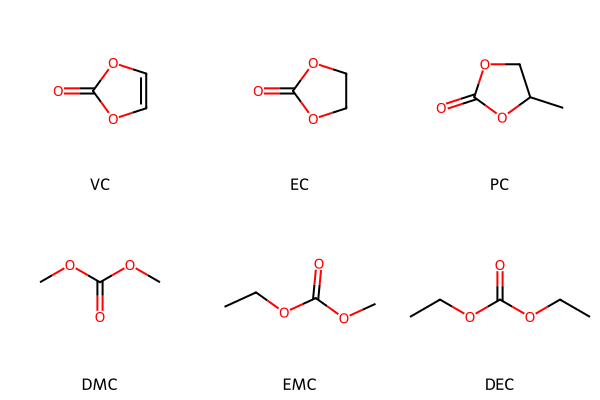

In [ ]:
# SMILES strings for each molecule
sm_dict = {
    'VC': 'c1coc(=O)o1',
    'EC': 'C1COC(=O)O1',
    'PC': 'CC1COC(=O)O1',
    'DMC': 'COC(=O)OC',
    'EMC': 'CCOC(=O)OC',
    'DEC': 'CCOC(=O)OCC'
}

Draw.MolsToGridImage([Chem.MolFromSmiles(sm_dict[mol]) for mol in sm_dict], legends=list(sm_dict.keys()))

For this tutorial, we prepared in advance a collection of atomic configurations (small subset from [this paper](https://doi.org/10.1021/acs.jpcb.2c03746)). Let's understand the data! We start by loading the raw configurations with no `labels` (energy, forces). The atomic `configurations`are stored in the [extxyz](https://docs.ase-lib.org/ase/io/formatoptions.html#extxyz) format and can be accessed using [ASE](https://wiki.fysik.dtu.dk/ase/index.html) as shown below:

In [ ]:
db = read('data/solvent_configs.xyz', ':') #read in list of configs

print("Number of configs in database: ", len(db))
print("Number of atoms in each config: ", np.array([len(at) for at in db]))
print("Number of atoms in the smallest config: ", np.min([len(at) for at in db])) #test if database contains isolated atoms
print("Information stored in config.info: \n", db[10].info) #check info
print("Information stored in config.arrays: \n", db[10].arrays)

Number of configs in database:  5000
Number of atoms in each config:  [24 22 25 ... 25 32 40]
Number of atoms in the smallest config:  8
Information stored in config.info: 
 {}
Information stored in config.arrays: 
 {'numbers': array([6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 8, 8, 6, 6, 6, 1, 1, 6, 1, 1,
       1, 1, 1, 1, 1, 1]), 'positions': array([[ 2.42930269,  5.21925545, -2.44555688],
       [ 1.36888075,  4.36736107, -3.07848001],
       [ 1.0430907 ,  3.33270121, -2.205446  ],
       [ 1.83499873,  3.2705152 , -1.20140588],
       [ 2.83662271,  4.2916441 , -1.29654086],
       [ 3.20092463,  5.52685308, -3.12019396],
       [ 1.98896468,  6.07220507, -2.07261896],
       [ 0.15712669,  2.55914021, -2.58440089],
       [ 3.80655074,  3.73805737, -1.62337792],
       [ 3.03487277,  4.82053137, -0.40139091],
       [-1.35643137, -2.96665978,  1.35700715],
       [-1.21188033, -2.7462728 ,  0.1501831 ],
       [-0.54117233, -3.68505168,  2.08627701],
       [-2.42475724, -2.65949082,  

At this point, each configuration is a collection of atoms: atomic number (Z) (`numbers` array) and positions (R) (`positions` array), with no additional information (`config.info`).
<br><br>
Let's identify the molecules and label molecular clusters. This will make it easier to inspect the data set and, later, test the accuracy of the potential on describing inter-molecular interactions.

Molecule identification is achieved using the `wrap_molecs` function from the [aseMolec package](https://github.com/imagdau/aseMolec), shown here for the first 100 frames `db[:100]`.

In [ ]:
aa.wrap_molecs(db[:100], prog=False) #identify molecules and label molecular clusters, showcase: first 100 frames
# write('data/solvent_molecs.xyz', db) #save full result
print("Information stored in config.info: \n", db[10].info)
print("Information stored in config.arrays: \n", db[10].arrays)

Information stored in config.info: 
 {'Nmols': 2, 'Comp': 'DEC(1):EC(1)'}
Information stored in config.arrays: 
 {'numbers': array([6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 8, 8, 6, 6, 6, 1, 1, 6, 1, 1,
       1, 1, 1, 1, 1, 1]), 'positions': array([[ 2.42930269,  5.21925545, -2.44555688],
       [ 1.36888075,  4.36736107, -3.07848001],
       [ 1.0430907 ,  3.33270121, -2.205446  ],
       [ 1.83499873,  3.2705152 , -1.20140588],
       [ 2.83662271,  4.2916441 , -1.29654086],
       [ 3.20092463,  5.52685308, -3.12019396],
       [ 1.98896468,  6.07220507, -2.07261896],
       [ 0.15712669,  2.55914021, -2.58440089],
       [ 3.80655074,  3.73805737, -1.62337792],
       [ 3.03487277,  4.82053137, -0.40139091],
       [-1.35643137, -2.96665978,  1.35700715],
       [-1.21188033, -2.7462728 ,  0.1501831 ],
       [-0.54117233, -3.68505168,  2.08627701],
       [-2.42475724, -2.65949082,  2.02500916],
       [ 0.77742571, -4.09808683,  1.66831815],
       [-3.53945827, -1.88707876,  1.42200

Note the additional information for each atomic config: number of molecules `Nmols`, molecular composition `Comp` (e.g `DEC(1):EC(1)` means the config comprises a dimer with 1 DEC molecule and 1 EC molecule) and molecular ID `molID`. Running the code for the full 5000 configurations can be slow, let's just load the final result (`data/solvent_molecs.xyz`).
<br><br>
Let's explore the data further! First, inspect the distribution of configs by number of molecules

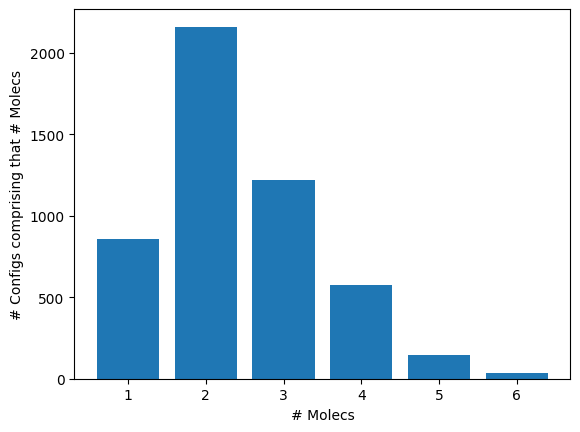

In [ ]:
db = read('data/solvent_molecs.xyz', ':')

### TODO ###
# Fill in the variable that stores the number of molecules
Nmols = np.array([at.info["Nmols"] for at in db]) #collect the number of molecules across all data
### END  ###

plt.hist(Nmols, align='left', bins=[1,2,3,4,5,6,7], rwidth=0.8);
plt.xlabel('# Molecs');
plt.ylabel('# Configs comprising that # Molecs');

There are just under 1000 configs comprising of single molecules and more than 2000 dimers. The largest configs contain clusters of six molecules.

We can check the distribution of molecular compositions for each cluster size. Let's start with cluster size = 6.

In [ ]:
from collections import Counter
### TODO ###
# make a list of all configs with cluster size of 6
cluster_size = 6
Nmol_configs = [at for at in db if at.info["Nmols"] == cluster_size]
Nmol_counts = dict(Counter([at.info["Comp"] for at in Nmol_configs]))
### END  ###
Nmol_counts

{'DEC(2):EC(1):PC(3)': 1,
 'DMC(1):EC(1):EMC(2):PC(1):VC(1)': 2,
 'DEC(2):EC(1):EMC(1):PC(1):VC(1)': 3,
 'DEC(1):DMC(2):EC(1):EMC(2)': 1,
 'DEC(1):DMC(2):EC(2):EMC(1)': 2,
 'DEC(1):DMC(2):PC(2):VC(1)': 1,
 'DEC(2):EC(2):EMC(1):PC(1)': 5,
 'DEC(1):DMC(1):EC(1):EMC(2):VC(1)': 1,
 'DEC(1):DMC(2):EC(1):EMC(1):VC(1)': 1,
 'DEC(3):EC(1):PC(2)': 1,
 'DEC(1):EC(2):EMC(1):PC(1):VC(1)': 4,
 'DEC(1):DMC(1):EMC(2):PC(1):VC(1)': 2,
 'DEC(1):EC(1):EMC(2):PC(1):VC(1)': 1,
 'DEC(1):DMC(2):EMC(1):PC(2)': 3,
 'DMC(1):EMC(1):PC(3):VC(1)': 1,
 'DMC(4):EMC(1):PC(1)': 2,
 'DEC(1):EC(3):PC(2)': 2,
 'DMC(3):EMC(1):PC(2)': 2,
 'DEC(1):DMC(1):EC(2):EMC(2)': 1,
 'DEC(2):EC(1):EMC(1):PC(2)': 1}

Now, let's do it for all the cluster sizes!
<br>
Please copy-paste from the above code cell as you see fit.

In [ ]:
comp_dict

{1: {'DMC(1)': 145,
  'PC(1)': 138,
  'EC(1)': 244,
  'EMC(1)': 107,
  'DEC(1)': 132,
  'VC(1)': 93},
 2: {'DMC(1):EC(1)': 179,
  'DMC(1):PC(1)': 102,
  'DMC(1):EMC(1)': 128,
  'EMC(1):PC(1)': 117,
  'DEC(1):PC(1)': 141,
  'DEC(1):EC(1)': 164,
  'EC(1):PC(1)': 111,
  'EC(1):VC(1)': 103,
  'EMC(2)': 132,
  'DEC(2)': 133,
  'DEC(1):VC(1)': 117,
  'DEC(1):EMC(1)': 162,
  'EMC(1):VC(1)': 83,
  'DEC(1):DMC(1)': 90,
  'EC(1):EMC(1)': 137,
  'DMC(1):VC(1)': 36,
  'DMC(2)': 30,
  'PC(2)': 92,
  'PC(1):VC(1)': 71,
  'EC(2)': 23,
  'VC(2)': 10},
 3: {'VC(3)': 157,
  'EC(3)': 138,
  'DEC(2):EC(1)': 10,
  'EMC(1):PC(1):VC(1)': 13,
  'DMC(2):EC(1)': 30,
  'DEC(1):EC(1):VC(1)': 11,
  'DMC(3)': 232,
  'EC(1):PC(1):VC(1)': 16,
  'PC(3)': 249,
  'EMC(1):VC(2)': 9,
  'DEC(3)': 24,
  'DEC(1):EC(1):PC(1)': 16,
  'DEC(1):DMC(1):PC(1)': 11,
  'EMC(3)': 19,
  'DEC(2):EMC(1)': 19,
  'EMC(1):PC(2)': 6,
  'EC(1):EMC(1):PC(1)': 9,
  'DMC(1):EMC(1):VC(1)': 10,
  'DEC(1):VC(2)': 4,
  'DEC(2):VC(1)': 7,
  'DEC(1):E

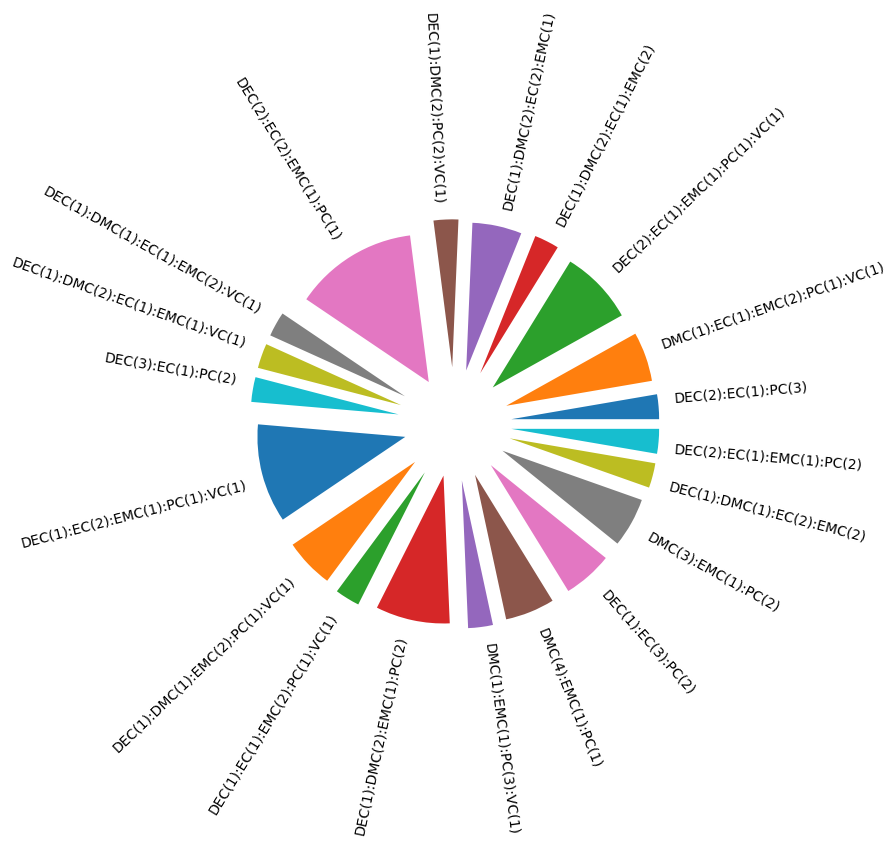

In [ ]:
comp_dict = {}
### TODO ###
for cluster_size in range(1, 7): # what is the smallest cluster size in the dataset? the largest?
    Nmol_configs = [at for at in db if at.info["Nmols"] == cluster_size]
    Nmol_counts = dict(Counter([at.info["Comp"] for at in Nmol_configs]))
    comp_dict[cluster_size] = Nmol_counts
### END ###

Nmol = 6 #show distribution of compositions for cluster size 6
plt.pie(comp_dict[Nmol].values(),
       labels=comp_dict[Nmol].keys(),
        explode=10/(25+np.array(list(comp_dict[Nmol].values()))),
        rotatelabels =True);

Do we see a good distribution of compositions at cluster size 6?

Check the distribution for other cluster sizes: `Nmol = 1, 2, 3, 4, 5`. Find out if all isolated molecules are present and well sampled.

We have six molecules, so there should be 6x7/2 dimers present, are all dimers sampled?

Where is there class imbalance?

### A1.2 Labeling Data with XTB Values

If we're convinced that the training set is quite diverse (i.e., samples many compositions and molecular cluster sizes), it's time to move on!

The next step is to prepare the reference data (energies, forces) to train the model on. We will do this using the Semiempirical Tight Binding level of theory with [XTB](https://xtb-docs.readthedocs.io/en/latest/). Usually, we would here evaluate an expensive **DFT or quantum chemistry methods**. XTB is much less accurate than these methods for these systems, but it is fast and it will serve as a good example.
<br><br>
#### **Isolated atoms energies**
Notice the data set contains isolated molecules but no isolated atoms (Think: how do you know this?)

MACE (and other MLIPs) fit to atomization energies (eV) which is total energy minus the energy of each atom in vacuum $(E^{0})$:
$$
E^{\rm atm} = E^{\rm tot}-\sum_i^{N} E^{0}
$$
It is essential that you compute the energies of the isolated atoms with your reference method on top of the dataset.
If you are using a dataset from the internet without that information, we will explain later how MACE can estimate these energies.

In our specific example, all molecules comprise of three chemical elements and we will need to compute $(E^{0})$ for each of them:

$$
E^{\rm atm} = E^{\rm tot}-\sum_i^{N_H} E^{H}_i-\sum_i^{N_C} E^{C}_i-\sum_i^{N_O} E^{O}_i
$$

Let us add three frames containing Hydrogen H, Carbon C and Oxygen O to the dataset and label them as `config_type=IsolatedAtom`

In [ ]:
db = read('data/solvent_molecs.xyz', ':')
print("Number of configs in database before adding isolated atoms: ", len(db))
db = [Atoms('H'), Atoms('C'), Atoms('O')] + db #add isolated atoms to the database

for at in db[:3]:
    at.info['config_type'] = 'IsolatedAtom'

print("Number of configs in database after adding isolated atoms: ", len(db))

Number of configs in database before adding isolated atoms:  5000
Number of configs in database after adding isolated atoms:  5003


We are now ready to compute the energy and forces with XTB (usually you would run DFT at the stage):

In [ ]:
try:
  xtb_calc = XTB(method="GFN2-xTB")

  for at in tqdm(db[:15]): #showcase: first 15 frames
      at.calc = xtb_calc
      at.info['energy_xtb'] = at.get_potential_energy()
      at.arrays['forces_xtb'] = at.get_forces()
  # write('data/solvent_xtb.xyz', db) #save full result

  print("Information stored in config.info: \n", db[13].info) #check info
  print("Information stored in config.arrays: \n", db[13].arrays)
except:
  print("xtb can't be found skipping this and using cached data.")

100%|██████████| 15/15 [00:06<00:00,  2.15it/s]

Information stored in config.info: 
 {'Nmols': np.int64(2), 'Comp': 'DEC(1):EC(1)', 'energy_xtb': -1323.8105075135995}
Information stored in config.arrays: 
 {'numbers': array([6, 8, 6, 8, 6, 1, 1, 8, 1, 1, 6, 8, 8, 8, 6, 6, 6, 1, 1, 6, 1, 1,
       1, 1, 1, 1, 1, 1]), 'positions': array([[ 2.42930269,  5.21925545, -2.44555688],
       [ 1.36888075,  4.36736107, -3.07848001],
       [ 1.0430907 ,  3.33270121, -2.205446  ],
       [ 1.83499873,  3.2705152 , -1.20140588],
       [ 2.83662271,  4.2916441 , -1.29654086],
       [ 3.20092463,  5.52685308, -3.12019396],
       [ 1.98896468,  6.07220507, -2.07261896],
       [ 0.15712669,  2.55914021, -2.58440089],
       [ 3.80655074,  3.73805737, -1.62337792],
       [ 3.03487277,  4.82053137, -0.40139091],
       [-1.35643137, -2.96665978,  1.35700715],
       [-1.21188033, -2.7462728 ,  0.1501831 ],
       [-0.54117233, -3.68505168,  2.08627701],
       [-2.42475724, -2.65949082,  2.02500916],
       [ 0.77742571, -4.09808683,  1.66831815

The updated data contains one energy value for each config `energy_xtb` and the `forces_xtb` on each atom. Latest version of [ASE](https://wiki.fysik.dtu.dk/ase/index.html) does not support simple names such as `energy` and `forces` so we append `_xtb`. The entire computation takes about `25 mins` for the 5003 configs. We have precomputed the data, so we can simply load the final result. Let's check the $E^0$ values and atomization energies:

In [ ]:
db = read('data/solvent_xtb.xyz', ':15')

print("E0s: \n", ea.get_E0(db, tag='_xtb'))
print("Total energy per config: \n", ea.get_prop(db, 'info', 'energy_xtb', peratom=False)[13])
print("Toal energy per atom: \n", ea.get_prop(db, 'info', 'energy_xtb', peratom=True)[13])
print("Atomization energy per config: \n", ea.get_prop(db, 'bind', prop='_xtb', peratom=False)[13])
print("Atomization energy per atom: \n", ea.get_prop(db, 'bind', prop='_xtb', peratom=True)[13])

E0s: 
 {'H': np.float64(-10.707211383396714), 'C': np.float64(-48.847445262804705), 'O': np.float64(-102.57117256025786)}
Total energy per config: 
 -1323.8105075135763
Toal energy per atom: 
 -47.278946696913444
Atomization energy per config: 
 -167.70295068203745
Atomization energy per atom: 
 -5.9893910957870515


Good! We get about -6 $\rm eV/atom$ which is largely dominated by the energy of the [covalent bonds](https://en.wikipedia.org/wiki/Bond-dissociation_energy#:~:text=of%20a%20solvent.-,Representative%20bond%20enthalpies,-%5Bedit%5D). Remember, the largest contribution to the total energy comes from $E^0$ and then from covalent bonds. The noncovalent interactions contribute a very small amount to the total energy, yet they are crucial for molecular dynamics.

## A2. Understanding MACE hyper parameters and interface

In order to train a MACE potential, one needs to create a configuration file that specifies three kind of information:
 1. Choice your model hyper-parameters.
 2. Specification of the data.
 3. Selection of your optimization parameters.

These informations are required in order to call the mace training script called `mace_run_train`.

The following section will cover in detail all of these three steps.

### A2.1 Model parameters

MACE has different hyper parameters that controls the degree of accuracy and expressivity of the model. Setting these parameters is a trade off between accuracy and computational cost. Most MACE parameters have robust and well tested defaults. We call them here "Parameters to keep to default values" but mention them for general knowledge. The "Hyper Parameters to Change" are hyper parameters that need to be adjusted as they can be task or system dependent.

### Hyper Parameters to Change:

- **`--num_channels`: Number of channels**
  
  Determines the size of the model. The recommended value is `--num_channels=128` but other potential values are `64` for a faster model or `256` for a large but more accurate model.
  
  
- **`max_L`: Symmetry of the messages**

  Determines the symmetry of the messages. A value of `--max_L=0` means MACE will pass only invariant information between neigborhoods. It is the parameter **that affects the most the computational speed and the accuracy of the model**. `--max_L=0` are the fastest model, use them to train cheap model to run large and long simulations. `--max_L=1` is the default value, it is a good compromise between speed and accuracy. It is recommended to start with that value for a new project. `--max_L=2` are the most accurate models, use them to train very accurate but slower models.
  

- **`--r_max`: The cutoff radius**
  
  The cutoff used to create the local environment in each layer. `r_max=5.0` means atoms separated by a distance of more than 5.0 Å do not directly communicate in a single layer. When the model has multiple message-passing layers, atoms further than 5.0 Å can still communicate through later messages if intermediate proxy atoms exist. The effective receptive field of the model is `num_interactions * r_max`. The larger the `r_max`, the slower the model will be. It is recommended to use values between 4.0 Å and 7.0 Å.

---

### Hyper Parameters to keep to default values (for general knowledge):

- **`--num_interactions`: Message-passing layers**
  
  Controls the number of message-passing layers in the model. It should always be 2, and it is recommended not to modify it.


- **`--correlation`: The order of the many-body expansion**

  The body order that MACE induces at each layer. Choosing `--correlation=3` will create basis functions of up to 4-body (ijkl) indices, for each layer. If the model has multiple layers, the effective correlation order is higher. For example, a two-layer MACE with `--correlation=3` has an effective body order of 13.


- **`--max_ell`: Angular resolution**

  The angular resolution describes how well the model can describe angles. This is controlled by `max_ell` of the spherical harmonics basis (not to be confused with `max_L`). Larger values will result in more accurate but slower models. The default is `max_ell=3`, which is appropriate in most cases.


### A2.2 Optimization and data management parameters

### General training management:


- ##### `--name`: the name of the model
    This name will be used to form file names (model, log, checkpoints, results), so choose a distinct name for each experiment

- ##### `--model_dir, --log_dir, --checkpoints_dir, --results_dir`: directory paths
    These are the directories where each type of file is saved. For simplicity, we will save all files in the same directory.

### Data management:

- ##### `--train_file`: name of training dataset

    These are the configurations that will be use to train the model.

- ##### `--valid_file`: name of validation dataset
    An alternative way to choose the validation set is by using the `--valid_fraction` keyword. These data configs are used to estimate the model accuracy during training, but not for parameter optimization. The validation set also controls the stopping of the training. At each `--eval_interval` the model is tested on the validation set. The evaluation of these configs takes place in batches, which can be controlled by `--valid_batch_size`. If the accuracy of the model stops improving on the validation set for `--patience` number of epochs, the model will undergo **early stopping**.

- ##### `--test_file`: name of testing dataset

    This set is entirely independent and only gets evaluated at the end of the training process to estimate the model accuracy on an independent set.

- ##### `--E0s`: isolated atom energies

    Controls how `E0s` should be determined. The strongly recommended approach is to add these values to the training set with `config_type=IsolatedAtom` in `atoms.info` and set `E0s="isolated"`. If these values are not available, MACE can estimate them by least square regression over the available data `E0s="average"` which can lead to unintended consequences depending on how representative the data is.

- ##### `--energy_key, --forces_key` the key where these values are stored
    This key must coincide with the `ase.Atoms.info[key]/ase.Atoms.arrays[key]` where the energies and forces are stored in the ase.Atoms object. **It is very important to get them right**.

### Optimization:

- ##### `--device` computing device to use
    Can be CPU (`cpu`), GPU (`cuda`) or Apple Silicon (`mps`). Here we will use `cuda` since the GPU will be significantly faster than the CPU.

- ##### `--batch_size` number of configs evaluated in one batch
    Number of configs used to compute the gradients for each full update of the network parameters. This training strategy is called stochastic gradient descent because only a subset of the data (`batch_size`) is used to change the parameters at each update.

- ##### `--max_num_epochs` number of passes through the data
    An `epoch` is completed when the entire training data has been used once in updating the weights `batch` by `batch`. A new epoch begins, and the process repeats.

- ##### `--swa` protocol for loss weights
    During training you will notice energy errors are at first much higher than force errors, MACE implements a special protocol that increases the weight on the energy in the loss function (`--swa_energy_weight`) once the forces are sufficiently accurate. The starting epoch for this special protocol can be controlled by changing `--start_swa`.

- ##### `--seed` random number generator seed
    Useful for preparing committee of models.

**Now we are ready to fit our first MACE model!**

## A3. Fitting and Testing MACE models

**Let's fit our first MACE model to our data.**

Let's start by splitting the data into a train and test set.

In [ ]:
db = read('data/solvent_xtb.xyz', ':')
write('data/solvent_xtb_train_200.xyz', db[:203]) #first 200 configs plus the 3 E0s
write('data/solvent_xtb_test.xyz', db[-1000:]) #last 1000 configs

### A3.1 Fitting the model

We will now write our first configuration file, that contains all the information detailed above. This a template you can adapt to your own data later on. We will create a small invariant model in order to run fast in the limited time we have. **Try to understand each of the entries by looking at their explanations above**.

In [ ]:
%%writefile config/config-01.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 4.0
name: "mace01"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"
train_file: "data/solvent_xtb_train_200.xyz"
valid_fraction: 0.10
test_file: "data/solvent_xtb_test.xyz"
energy_key: "energy_xtb"
forces_key: "forces_xtb"
device: cuda
batch_size: 10
max_num_epochs: 100
swa: True
seed: 123

Writing config/config-01.yml


Normally you would call a script from the command line called `mace_run_train` (see https://mace-docs.readthedocs.io/en/latest/guide/training.html) and pass it a yaml file of parameters. Below we define a function to train mace from inside python instead.

In [ ]:
from mace.cli.run_train import main as mace_run_train_main

def train_mace(config_file_path):
    logging.getLogger().handlers.clear()
    sys.argv = ["program", "--config", config_file_path]
    mace_run_train_main()

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.


In [ ]:
train_mace("config/config-01.yml")

2026-08-03 22:39:35.480 INFO: ===========VERIFYING SETTINGS===========
2026-08-03 22:39:35.481 INFO: MACE version: 0.3.16
2026-08-03 22:39:35.481 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-03 22:39:35.528 INFO: ===========LOADING INPUT DATA===========
2026-08-03 22:39:35.529 INFO: Using heads: ['Default']
2026-08-03 22:39:35.529 INFO: Using the key specifications to parse data:
2026-08-03 22:39:35.530 INFO: Default: KeySpecification(info_keys={'energy': 'energy_xtb', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'forces_xtb', 'charges': 'REF_charges'})
2026-08-03 22:39:35.530 INFO: =============    Processing head Default     ===========
2026-08-03 22:39:35.610 INFO: Using isolated atom energies from training file
2026-08-03 22:39:35.618 INFO: Training set 1/1 [energy: 200, stress: 0, virials: 0, 

**Congratulations you have trained your first MACE model!!!**

In [ ]:
#remove checkpoints since they may cause errors on retraining a model with the same name but a different architecture
for file in glob.glob("MACE_models/*.pt"):
    os.remove(file)

### A3.2 Testing the model: simple RMSEs

Use the `mace_eval_configs` script to evaluate the trained model on both the train and test datasets. The script takes the arguments: `--configs` which specifies the file to evaluate, the path to the model in `--model` and the path to the output in `--output`. Here we call it from python again.

In [ ]:
os.makedirs("tests/mace01/", exist_ok=True)

In [ ]:
from mace.cli.eval_configs import main as mace_eval_configs_main

def eval_mace(configs, model, output):
    sys.argv = ["program", "--configs", configs, "--model", model, "--output", output]
    mace_eval_configs_main()

In [ ]:
#evaluate the training set
eval_mace(configs="data/solvent_xtb_train_200.xyz",
          model="MACE_models/mace01.model",
          output="tests/mace01/solvent_train.xyz")

#evaluate the test set
eval_mace(configs="data/solvent_xtb_test.xyz",
          model="MACE_models/mace01.model",
          output="tests/mace01/solvent_test.xyz")

2026-08-03 22:42:22.843 INFO: Using CPU
2026-08-03 22:42:25.091 INFO: Using CPU


We can compare MACE vs XTB accuracy on the train and test sets and for this we will use the [aseMolec](git@github.com:imagdau/aseMolec.git) package which implements some handy utilities for manipulating ase.Atoms and testing potentials, especially for molecular systems.

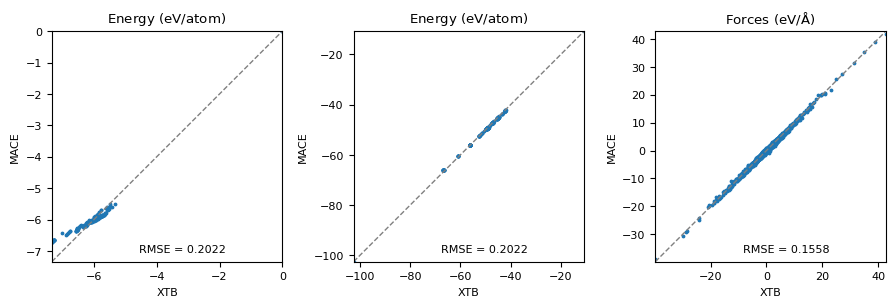

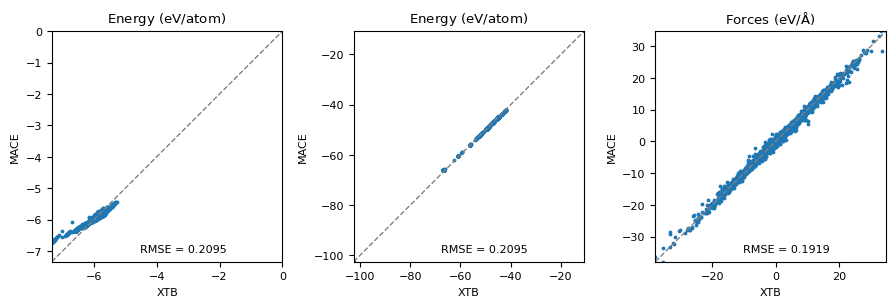

In [ ]:
def plot_RMSEs(db, labs):
    ea.rename_prop_tag(db, 'MACE_energy', 'energy_mace') #Backward compatibility
    ea.rename_prop_tag(db, 'MACE_forces', 'forces_mace') #Backward compatibility

    plt.figure(figsize=(9,6), dpi=100)
    plt.subplot(1,3,1)
    pp.plot_prop(ea.get_prop(db, 'bind', '_xtb', True).flatten(), \
                 ea.get_prop(db, 'bind', '_mace', True).flatten(), \
                 title=r'Energy $(\rm eV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,2)
    pp.plot_prop(ea.get_prop(db, 'info', 'energy_xtb', True).flatten(), \
                 ea.get_prop(db, 'info', 'energy_mace', True).flatten(), \
                 title=r'Energy $(\rm eV/atom)$ ', labs=labs, rel=False)
    plt.subplot(1,3,3)
    pp.plot_prop(np.concatenate(ea.get_prop(db, 'arrays', 'forces_xtb')).flatten(), \
                 np.concatenate(ea.get_prop(db, 'arrays', 'forces_mace')).flatten(), \
                 title=r'Forces $\rm (eV/\AA)$ ', labs=labs, rel=False)
    plt.tight_layout()
    return

train_data = read('tests/mace01/solvent_train.xyz', ':')
test_data = train_data[:3]+read('tests/mace01/solvent_test.xyz', ':') #append the E0s for computing atomization energy errors

plot_RMSEs(train_data, labs=['XTB', 'MACE'])
plot_RMSEs(test_data, labs=['XTB', 'MACE'])

These figures show correlation plots between XTB values and MACE predicted values for atomization energy per atom, the total energy per atom and forces. Do the RMSE values match the number printed at the end of the model training? These errors don't look too bad, and this MACE is a small model with few parameters. Significantly better accuracies can be achieved when training on larger models with more data.

### A3.3 Testing on the Intra/Inter decomposition:

As shown in this [paper](https://doi.org/10.1038/s41524-023-01100-w) one of the challenges associated with modelling molecular systems has to do with the  inter-molecular interactions.
Molecular dynamics is primarily driven by these inter-molecular interactions, however they are relatively small in comparison to covalent interactions and prove difficult to capture with MLIPs.
The paper introduces this protocol to decompose the force errors into [intra- and inter-] molecular RMSEs to gauge the quality of the potential separately on the two interaction scales. This approach can be summarized as follows:
1. Identify molecules (labeled **j**).  

2. Within each molecule **j** sum over all atomic forces (labeled **k**) to obtain the **translational** component:
$$F^{\rm trans}_j = \sum_{k \in j} f_{k}$$

3. Redistribute the molecular **translational** force onto individual atoms (labeled **i**) to obtain the atomic **translational** contributions:
$$f^{\rm trans}_i = \frac{m_i}{M_j} F^{\rm trans}_j$$

4. Similarly, compute the torque on the entire molecule:
$$T_j = \sum_{k \in j} f_{k} \times r_{k}$$

5. Compute the atomic **rotational** force contributions that give rise to the given molecular torque:
$$f^{\rm rot}_i = m_i r_i \times (I_j^{\alpha \beta})^{-1} T_j$$

6. Finally compute the **vibrational** contribution as the difference:
$$f^{\rm vib}_i = f_i - f^{\rm trans}_i - f^{\rm rot}_i$$

7. In this approach, the **Inter** is the sum of `trans` and `rot`, while the **Intra** is the `vib` component.

This force decomposition can be automatically obtained using the [aseMolec](https://github.com/imagdau/aseMolec) package as shown below:

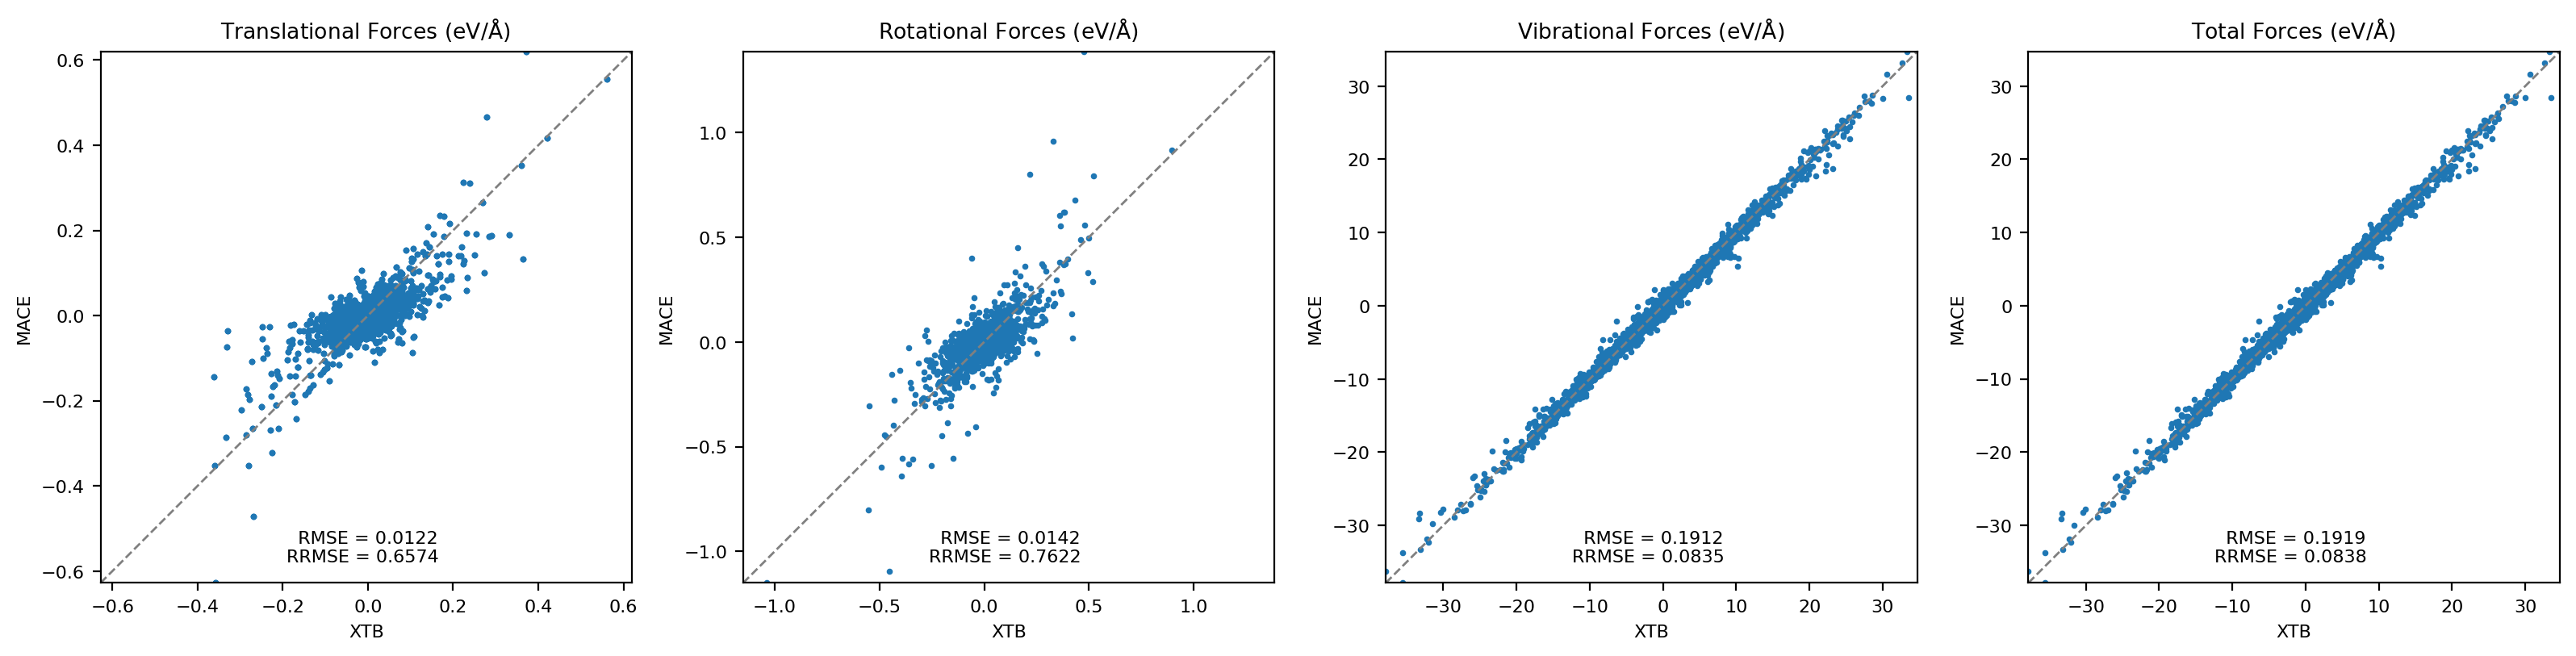

In [ ]:
db1 = read('tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db1, 'energy_xtb', 'energy') #Backward compatibility
ea.rename_prop_tag(db1, 'forces_xtb', 'forces') #Backward compatibility

db2 = read('tests/mace01/solvent_test.xyz', ':')
ea.rename_prop_tag(db2, 'MACE_energy', 'energy') #Backward compatibility
ea.rename_prop_tag(db2, 'MACE_forces', 'forces') #Backward compatibility

aa.extract_molecs(db1, intra_inter=True)
aa.extract_molecs(db2, intra_inter=True)

pp.plot_trans_rot_vib(db1, db2, labs=['XTB', 'MACE'])

Indeed, the translation and rotational part of the forces (related to inter-molecular interactions) is significantly harder to capture as evidenced by the larger errors. While the absolute RMSEs are smaller, the relative RMSEs are signifincatly larger for the inter-molecular components. Nevertheless, MACE errors are significantly lower than other models on these tests.

## A4. Molecular Dynamics with MACE

**Let's run your first simulation with MACE in ASE**

### A4.1 Is the dynamics stable?

Accuracy on fixed test sets is great, but molecular dynamics (MD) is the ultimate test. First, we care about stability, then accuracy: let's check if MACE gives stable dynamics. We will start by implementing a simple function to run Langevin dynamics. We initialize the temperature at 300 K and remove all translations and rotations.

In [ ]:
from ase.md.velocitydistribution import Stationary, ZeroRotation, MaxwellBoltzmannDistribution

import random
import os
import pylab as pl
from IPython import display

def simpleMD(init_conf, temp, calc, fname, s, T):
    init_conf.set_calculator(calc)

    #initialize the temperature
    random.seed(701) #just making sure the MD failure is reproducible
    MaxwellBoltzmannDistribution(init_conf, temperature_K=300) #initialize temperature at 300
    Stationary(init_conf)
    ZeroRotation(init_conf)

    dyn = Langevin(init_conf, 1.0*units.fs, temperature_K=temp, friction=0.1) #drive system to desired temperature

    %matplotlib inline

    time_fs = []
    temperature = []
    energies = []

    #remove previously stored trajectory with the same name
    os.system('rm -rfv '+fname)

    fig, ax = pl.subplots(2, 1, figsize=(6,6), sharex='all', gridspec_kw={'hspace': 0, 'wspace': 0})

    def write_frame():
            dyn.atoms.write(fname, append=True)
            time_fs.append(dyn.get_time()/units.fs)
            temperature.append(dyn.atoms.get_temperature())
            energies.append(dyn.atoms.get_potential_energy()/len(dyn.atoms))

            ax[0].plot(np.array(time_fs), np.array(energies), color="b")
            ax[0].set_ylabel('E (eV/atom)')

            # plot the temperature of the system as subplots
            ax[1].plot(np.array(time_fs), temperature, color="r")
            ax[1].set_ylabel('T (K)')
            ax[1].set_xlabel('Time (fs)')

            display.clear_output(wait=True)
            display.display(pl.gcf())
            time.sleep(0.01)

    dyn.attach(write_frame, interval=s)
    t0 = time.time()
    dyn.run(T)
    t1 = time.time()
    print("MD finished in {0:.2f} minutes!".format((t1-t0)/60))

Now we can run MD with MACE and compare it to the XTB dynamics. Let's try 2 picoseoncds at 1200 K, starting from a single molecule config:

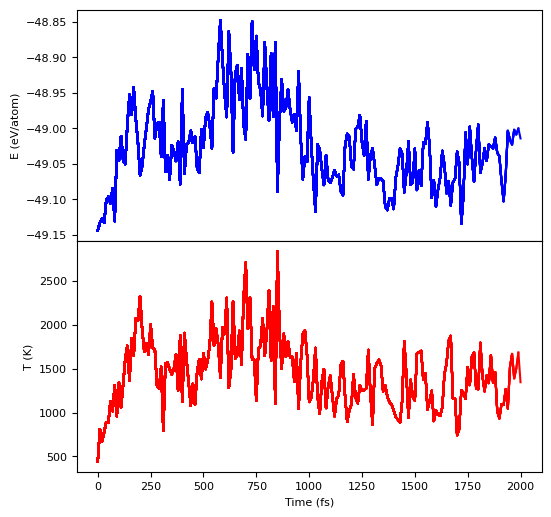

MD finished in 1.84 minutes!


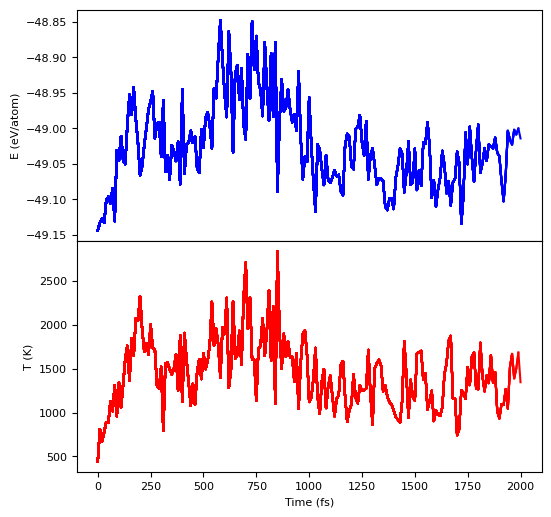

In [ ]:
 #let us start with a single molecule
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()

#we can use MACE as a calculator in ASE!
from mace.calculators import MACECalculator
mace_calc = MACECalculator(model_paths=['MACE_models/mace01_run-123_stagetwo.model'], device='cuda', default_dtype="float32")

simpleMD(init_conf, temp=1200, calc=mace_calc, fname='moldyn/mace01_md.xyz', s=10, T=2000)


In [ ]:
# the MACE trajectory we just generated
show_traj('moldyn/mace01_md.xyz')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

For reference, we can also run XTB dynamics from the same starting configuration.

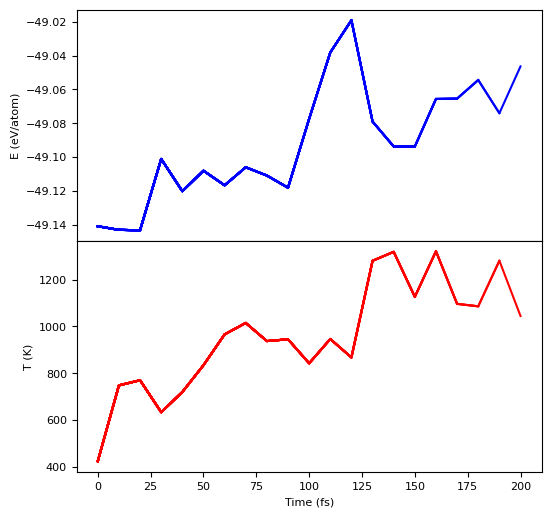

MD finished in 1.26 minutes!


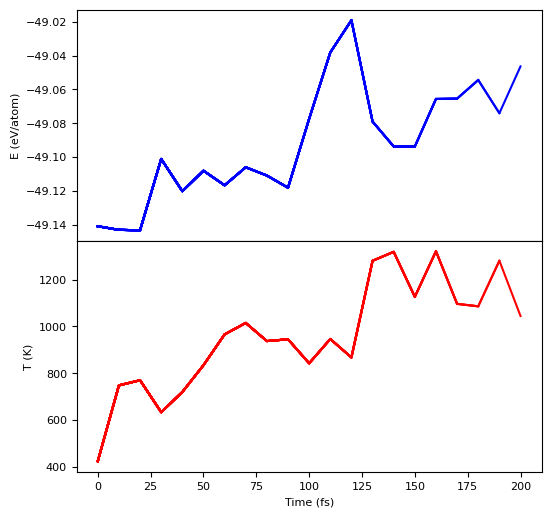

In [ ]:
# reinitialize the original config
init_conf = ea.sel_by_info_val(read('data/solvent_molecs.xyz',':'), 'Nmols', 1)[0].copy()

try:
  from xtb.ase.calculator import XTB
  xtb_calc = XTB(method="GFN2-xTB")
  simpleMD(init_conf, temp=1200, calc=xtb_calc, fname='moldyn/xtb_md_2.xyz', s=10, T=200)
except:
  print("xtb can't be found skipping this and using cached data.")



MACE dynamics finished in under 2 minutes, vs XTB would take over 14, so we stop after just 200 steps. This is the essence of MLIP: speeding up calculations that would otherwise take a long time to run. In this case, the speed-up is just one order of magnitude, but depending on the cost of the reference calculation, it can be many orders of magnitude for expensive Quantum Chemistry methods and large systems. Remember, the cost of MLIP is independent of the accuracy of the potential energy surface!

Let's visualize the trajectory:

In [ ]:
# The XTB reference. 'xtb_md.xyz' is the long pre-computed trajectory that ships with the
# repo; 'xtb_md_2.xyz' is the short one the cell above just produced, if XTB was available.
xtb_traj = 'moldyn/xtb_md.xyz' if os.path.exists('moldyn/xtb_md.xyz') else 'moldyn/xtb_md_2.xyz'
print(f'showing {xtb_traj}')
show_traj(xtb_traj)

showing moldyn/xtb_md.xyz


3Dmol.js failed to load for some reason. Please check your browser console for error messages.


Obtaining stable dynamics with so little training is a great result. Up until recently, most MLIPs would require a lot of training before MD was stable. MACE combines the lessons learned over 10-15 years in MLIP development, to achieve a smooth and regular potential energy surface, which minimizes the risk of unstable MD.

### A4.2 Is the dynamics accurate?

Are the different dynamics sampling the correct distributions? Let us check the radial distribution functions (RDF). The [aseMolec](https://github.com/imagdau/aseMolec) package provides functionality to do that:

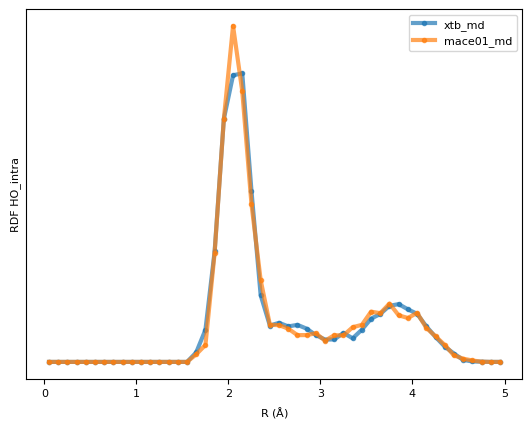

In [ ]:
tag = 'HO_intra' #choose one of 'HH_intra', 'HC_intra', 'HO_intra', 'CC_intra', 'CO_intra', 'OO_intra'

for f in ['xtb_md', 'mace01_md']:
    traj = read('moldyn/'+f+'.xyz', '50:') #ignore first 50 frames
    for at in traj:
        at.pbc = True #create a fake box for rdf compatibility
        at.cell = [100,100,100]
    rdf = aa.compute_rdfs_traj_avg(traj, rmax=5, nbins=50) #aseMolec provides functionality to compute RDFs
    plt.plot(rdf[1], rdf[0][tag], '.-', label=f, alpha=0.7, linewidth=3)

plt.legend();
plt.yticks([]);
plt.xlabel(r'R ($\rm \AA$)');
plt.ylabel('RDF '+tag);

Try it yourself! Inspect other RDF pairs (`C-O`, `H-C`), how well are they reproduced?

The trajectories here are stable and also quite accurate. This is still a relatively simple task: we chose a single molecule at relatively small temperatures (for a molecule) and only ran for 2 picoseconds. In practice, given enough time and high enough temperature the initial models will fail.

Experiment with the starting configs, temperatures, simulation length, see if you can find problems with the potentials! **Section 4.4 gives you a cell built for exactly this**, including automatic checks so you can tell a broken trajectory from a merely surprising one.

### A4.3 MD of a molecular liquid?

The MLIP was trained on clusters, can we simulate the liquid molecular environment?

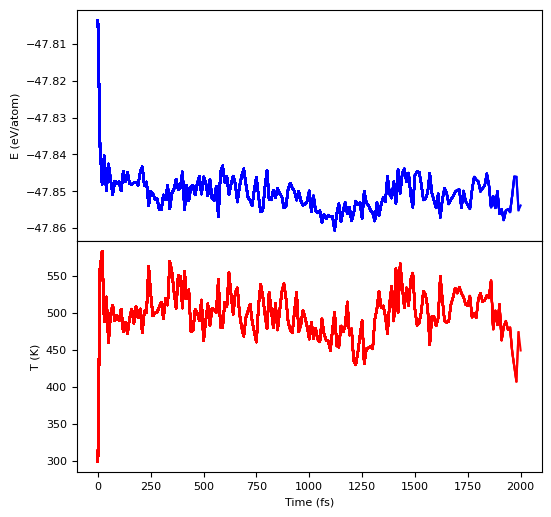

MD finished in 1.86 minutes!


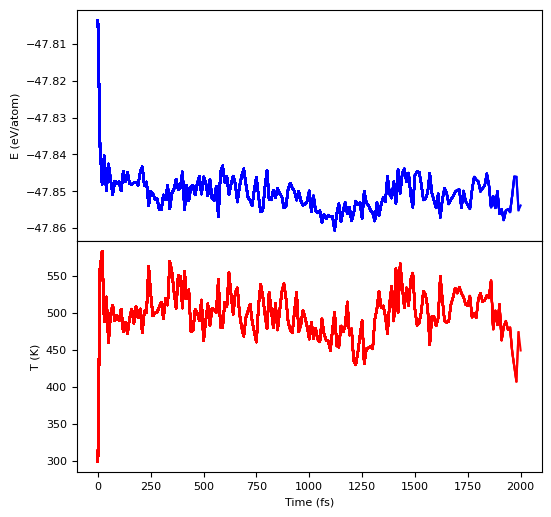

In [ ]:
init_conf = read('data/solvent_liquid.xyz') #read a liquid config with periodic boundary conditions
init_conf.center()
simpleMD(init_conf, temp=500, calc=mace_calc, fname='moldyn/mace01_md_liquid.xyz', s=10, T=2000)

This XTB calculator is non-periodic, so this dynamics would not be possible without an MLIP! Check for yourself, by replacing the calculator with `xtb`. The system is much larger than the example before (12 molecules vs just one). Let's view the trajectory:

In [ ]:
show_traj('moldyn/mace01_md_liquid.xyz')

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Transferability from clusters to the condensed phase environment is still an [open research](https://doi.org/10.1021/acs.jpcb.2c03746) question. If this works, it implies that we might be able to learn highly accurate Quantum Chemistry PES on molecular clusters and make predictions (density, diffusivity) for the condensed phase! This is new science!

---

That is the standard MLIP workflow: fit, check the errors, run dynamics. Every metric so far
has been an error *against the reference method we trained on* — a comparison of the model
with XTB, not of the model with reality.

**Part B changes the question.** We move to liquid water, train models on some
quantum-chemistry datasets, and ask whether they reproduce the density of water.

# Part B - Building models of water

Part A measured models against an XTB reference. But can we build a model that reflects experiment?

Water gives us a harder test. The density of liquid water is **0.997 g/cm3** at 25 C: we can see if our models can replicate this result.

## B1. Exploring the data


### B1.1 One configuration

`data/water_structures.xyz` is a sequence of snapshots of liquid
water - 64 molecules in a periodic box. Unlike the carbonate clusters in Part A, these
are **periodic**.

In [ ]:
water_raw = read('data/water_structures_raw.xyz', ':')
at = water_raw[0]
at_wrapped = at.copy()
at_wrapped.wrap()

print(f'{len(water_raw)} configurations')
print(f'this one: {len(at)} atoms = {sum(at.numbers == 8)} water molecules')
print(f'cell     {at.cell.lengths().round(3)} A,  angles {at.cell.angles().round(1)}')
print(f'periodic {at.pbc},  density {frame_density(at):.4f} g/cm3')
print(f'\nlabels on this file: info={dict(at.info)}  arrays={list(at.arrays)}')

show_traj(at)

490 configurations
this one: 192 atoms = 64 water molecules
cell     [12.984 12.984 12.984] A,  angles [90. 90. 90.]
periodic [ True  True  True],  density 0.8747 g/cm3

labels on this file: info={}  arrays=['numbers', 'positions']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
show_traj(at_wrapped)

### B1.2 Make the labels

In Part A, you labelled clusters with XTB to make training data. Here we do the same
thing with **GFN-FF**, a generic force field. It is thousands of times cheaper than DFT, but may not accurately reflect the energies and forces we need to understand water.

Let's generate labels for 15 molecules!

In [ ]:
# a helper function that calls the forcefield calculator

def gfnff_label(at, method='GFN-FF'):
    from xtb.ase.calculator import XTB
    calc = XTB(method=method)
    try:
        calc.calculate(at, properties=['energy', 'forces'], system_changes=[])
    except Exception as exc:
        if 'Virial' not in str(exc):
            raise
    return calc.results['energy'], calc.results['forces']

In [ ]:
labelled = []
sample = water_raw[:15]
for at in tqdm(sample):
    new = at.copy()
    ### TODO ###
    e, f = gfnff_label(at)
    new.info['FF_energy'] = e
    new.arrays['FF_forces'] = f
    ### END TODO ###

    labelled.append(new)

100%|██████████| 15/15 [00:40<00:00,  2.70s/it]


In [ ]:
# let's look at the labels!
one = labelled[0]
print('\n.info   ', one.info)
print('.arrays ', list(one.arrays))


.info    {'FF_energy': -594.310218338325}
.arrays  ['numbers', 'positions', 'FF_forces']


Based on this output, which labels you will use for energy_key and forces_key in a config file to train an MLIP on the GFN-FF dataset?


### B1.3 Which densities has it seen?

A model only knows how
energy varies with density if it has *seen* different densities.

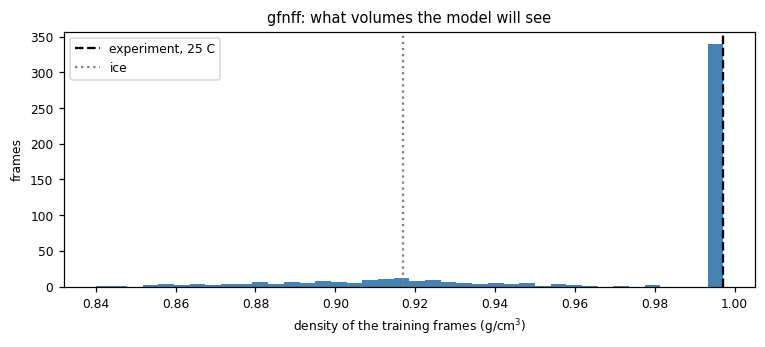

490 frames, density 0.840 - 0.997 g/cm3


In [ ]:
BASELINE_DATASET = 'gfnff'

plot_density_distribution(BASELINE_DATASET)

## B2. A starting model

Let's build a starting model: the cheap force-field reference, 100
configurations, and the smallest sensible network.

`r_max` deserves a note. The boxes are 12.4-13.2 A across, so **half the shortest cell
vector is about 6.2 A**. A cutoff above that reaches past the periodic boundary and atoms
start interacting with copies of themselves. Keep `r_max` at or below 6.0.

In [ ]:
BASELINE_N_TRAIN = 50

train_file, test_file = make_training_set(BASELINE_DATASET, n_train=BASELINE_N_TRAIN,
                                          n_test=100, seed=0)

gfnff: GFN-FF (generic force field, no electronic structure)
  50 training and 100 test frames, densities 0.847 - 0.997 g/cm3
Created files: data/water_train_gfnff_50.xyz, data/water_test_gfnff.xyz


In [ ]:
%%writefile config/config-water00.yml

model: "MACE"
num_channels: 32
max_L: 0
r_max: 5.0

name: "water00"
model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"

### TODO ###
train_file: "data/water_train_gfnff_50.xyz"
test_file: "data/water_test_gfnff.xyz"
energy_key: "FF_energy"
forces_key: "FF_forces"
### END TODO ###

valid_fraction: 0.10
E0s: "average"               # no isolated atoms in this data, so fit the references
device: cuda
batch_size: 5
max_num_epochs: 50

swa: True
seed: 123

Overwriting config/config-water00.yml


In [ ]:
for f in glob.glob('MACE_models/water00*'):
    os.remove(f)

train_mace('config/config-water00.yml')

2026-08-04 04:23:12.034 INFO: ===========VERIFYING SETTINGS===========
2026-08-04 04:23:12.035 INFO: MACE version: 0.3.16
2026-08-04 04:23:12.037 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 04:23:12.043 INFO: ===========LOADING INPUT DATA===========
2026-08-04 04:23:12.044 INFO: Using heads: ['Default']
2026-08-04 04:23:12.046 INFO: Using the key specifications to parse data:
2026-08-04 04:23:12.047 INFO: Default: KeySpecification(info_keys={'energy': 'FF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'FF_forces', 'charges': 'REF_charges'})
2026-08-04 04:23:12.048 INFO: =============    Processing head Default     ===========
2026-08-04 04:23:12.198 INFO: Training set 1/1 [energy: 50, stress: 0, virials: 0, dipole components: 0, head: 50, elec_temp: 0, total_charge: 0, polarizability: 0,

In [ ]:
register_model('water00', BASELINE_DATASET)

water00: trained on gfnff (data/water_train_gfnff_50.xyz)


## B3. Ask it for the density of water

Here is the thing that makes density a different kind of test from anything in Part A! The model is trained on the task of learning the energy and forces of an arrangement of atoms. To find the density you have to *run the dynamics* and see what volume the liquid settles at, when you hold the pressure and temperature constant.

**STEP 1 - run molecular dynamics with your model.**
This step produces a trajectory with N, Pressure, and Temperature held (close to) constant

2026-08-04 04:34:19.088 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 04:34:19.090 INFO: Using head Default out of  ['Default']
2026-08-04 04:34:19.091 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
  water00           2.85 min   <T> =  297.8 K   rho_final = 0.382 g/cm3

trajectory written to moldyn/water_npt_water00.xyz


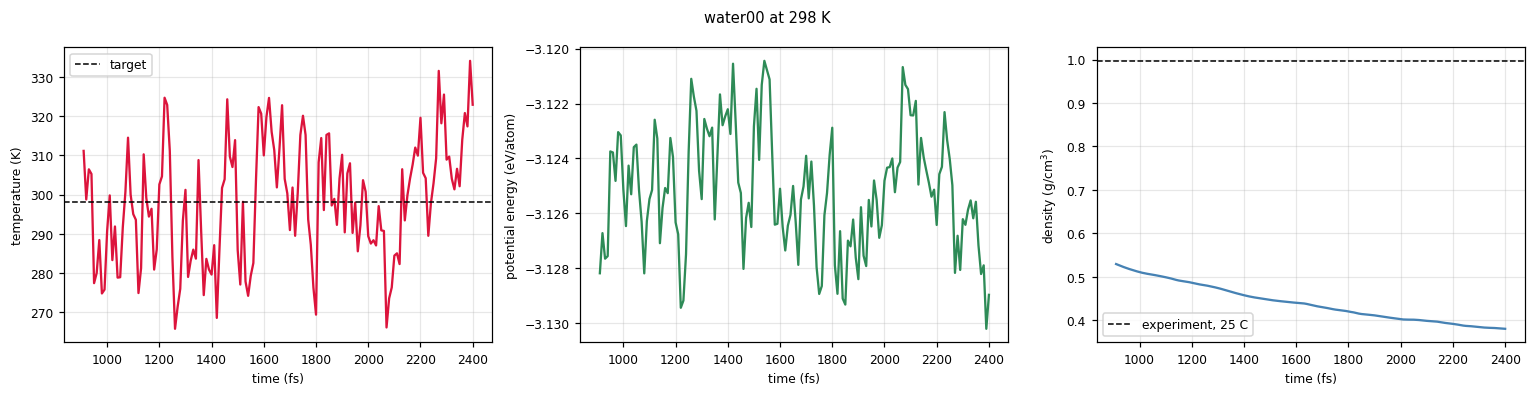

temperature  297.8 +/- 15.2 K (target 298.1)
energy drift -0.001 meV/atom per ps   (large and one-signed means trouble)


In [ ]:
from mace.calculators import MACECalculator

WATER_MODELS = {}
WATER_MODELS['water00'] = MACECalculator(model_paths=[find_model('water00')],
                                         device='cuda', default_dtype='float32')

# Start from an equilibrated configuration from the data itself
rho_raw = np.array([frame_density(a) for a in water_raw])
WATER_BOX = water_raw[int(np.argmin(np.abs(rho_raw - 0.997)))].copy()
WATER_BOX.calc = None
WATER_TEMP_K = 298.15

fname, trace = run_water_npt('water00', WATER_MODELS['water00'], WATER_BOX,
                             temp=WATER_TEMP_K)
print(f'\ntrajectory written to {fname}')
plot_md(trace, 'water00 at 298 K')

**STEP 2 - compute the density from that trajectory.**
The mass is fixed - the same 64 molecules throughout - so all that varies is the box
volume. Average it over the part of the run where it had stopped changing.

In [ ]:
result = density_from_trajectory(fname)

water_density['water00'] = {**trace, **result}

ref = water_density_ref(WATER_TEMP_K - 273.15)
print(f'\nexperiment at 25 C: {ref:.4f} g/cm3')
print(f'error: {100*(result["rho_mean"] - ref)/ref:+.1f}%')

150 frames; averaging over the last 75
mass 1153.0 amu (constant)   mean volume 4750.7 A^3
density = 1153.0 x 1.660539 / 4750.7 = 0.403 +/- 0.053 g/cm3   [NOT CONVERGED]
  scatter 0.041, trend implies 0.053 across the window (tol 0.015)

experiment at 25 C: 0.9970 g/cm3
error: -59.5%


### Was that dynamics healthy?

A temperature far from target, or an energy drifting steadily in one direction, means the
number above is not reliable.

**If you see a consistent drift (convergence failure):**
Try increasing `equil`. However, the larger the numbers, the longer your simulation will take to run.

Note: The barostat approaches its target
exponentially with time constant `taup_fs`, so equilibration needs about three of those
before the volume has stopped moving. For example, (`taup_fs=500`, `equil=1500`) are a
matched pair. If you shorten one, shorten the other — `taup_fs=300, equil=900`.

In [ ]:
# The configuration the density came from, at the end of the run.
show_traj(water_density['water00']['final'])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
# wrap structure
atoms = water_density['water00']['final'].copy()
atoms.wrap()
show_traj(atoms)

##### Questions

1. Did the temperature hold at 298 K?
2. Is the density trace flat, or still sloping at the end?
3. Compare the final structure with the starting one. Anything obviously wrong?

## B4. The other datasets

So far, we trained a model with force field energies.

We also have additional datasets at DFT level of theory. **How much of the error comes from the
reference method rather than from the machine learning?**

Experiment with the datasets and find out!

| dataset key | file | frames | level of theory | citation |
|---|---|---|---|---|
| — | `data/water_structures_raw.xyz` | 490 | none — positions only |||
| `gfnff` | `data/water_gfnff.xyz` | 490 | **GFN-FF** — generic force field, no electronic structure | |
| `revpbe_d3` | `data/water_structures.xyz` | 490 | **revPBE-D3** — GGA + dispersion ||
| `rpbe_d3` | `data/water_rpbe_d3_liquid_64mol.xyz` | 490 | **RPBE-D3** — a *different* GGA + dispersion | Morawietz *et al.*, *PNAS* **113**, 8368 (2016); extended by Wohlfahrt *et al.*, *JCP* **153**, 144710 (2020) |
| `revpbe0_d3` | `data/water_revpbe0_64mol.xyz` | 400 | **revPBE0-D3** — hybrid, adds exact exchange | Cheng, Engel, Behler, Dellago & Ceriotti, *PNAS* **116**, 1110 (2019) |

All are 64 molecules (192 atoms) in a cubic periodic box, densities spanning 0.84–0.997 g/cm³.


Before you use a new dataset, make sure you know what the energy and force labels are for that file! Check below:

In [ ]:
data_path = "data/water_rpbe_d3_liquid_64mol.xyz" # e.g., data/water_gfnff.xyz
if os.path.exists(data_path):
    a = read(data_path, '0')
    print(f'{data_path:12s} .info {dict(a.info)}')
    print(f'{data_path:12s} .arrays {list(a.arrays)}')
else:
    print(f'file {data_path} not found')

data/water_rpbe_d3_liquid_64mol.xyz .info {'REF_energy': np.float64(-133336.527059976)}
data/water_rpbe_d3_liquid_64mol.xyz .arrays ['numbers', 'positions', 'REF_forces']


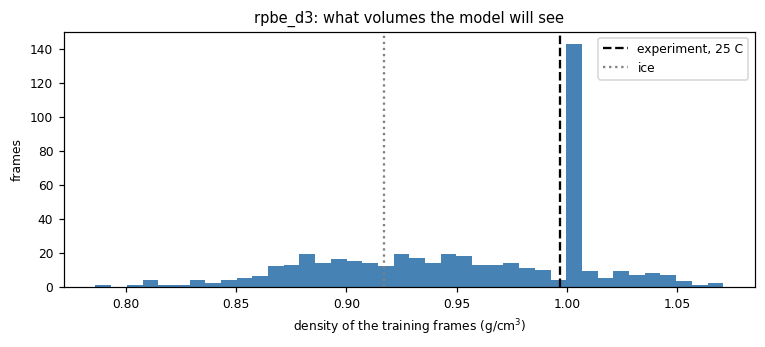

490 frames, density 0.786 - 1.071 g/cm3


In [ ]:
# Explore the data! Are the density distributions different?
DATASET = "rpbe_d3" # e.g., gfnff, revpbe_d3
plot_density_distribution(DATASET)

### Make your training set!

Pick a dataset and size. 390 is the biggest dataset you can choose -- why is that?

In [ ]:
### TODO ###
DATASET = 'rpbe_d3'      # gfnff / revpbe_d3 / rpbe_d3 / revpbe0_d3
N_TRAIN = 50              # 50 / 100 / 250 / 390
### END TODO ###

train_file, test_file = make_training_set(DATASET, n_train=N_TRAIN, n_test=100, seed=0)

print("Here are all the training datasets that you have access to now -- you can make more!")
data_files = os.listdir('data')
[f for f in data_files if "water" in f]

rpbe_d3: RPBE-D3 (a different GGA, FHI-aims all-electron)
  50 training and 100 test frames, densities 0.809 - 1.057 g/cm3
Created files: data/water_train_rpbe_d3_50.xyz, data/water_test_rpbe_d3.xyz
Here are all the training datasets that you have access to now -- you can make more!


['water_train_rpbe_d3_390.xyz',
 'water_revpbe0_64mol.xyz',
 'water_structures.xyz',
 'water_train_gfnff_100.xyz',
 'water_test_rpbe_d3.xyz',
 'water_gfnff.xyz',
 'water_structures_raw.xyz',
 'water_test_gfnff.xyz',
 'water_rpbe_d3_liquid_64mol.xyz',
 'water_train_rpbe_d3_50.xyz']

## B5. Build more models

Four independent levers:

| lever | where | what it tests |
|---|---|---|
| **amount of data** | `N_TRAIN` above | is 50 frames enough? is 400? |
| **level of theory** | `DATASET` above | does a better reference give a better density? |
| **architecture** | the config below | do bigger models help, and what do they cost? |
| **fine-tuning** | B5.2 | can a foundation model do more with the same data? |

Change one at a time if you want to be able to attribute the result. **Set `train_file`
and `test_file`, as well as `energy_key` and `forces_key` accordingly**

### B5.1 A bigger network

Memory scales as roughly `num_channels` x (irreps from `max_L`) x `r_max`^3, and those
multiply: going from 32/0/5.0 to 128/1/7.0 is about 45x and will exhaust a 40 GB GPU. If
you hit `CUDA out of memory`, drop `batch_size` first - it changes memory but not the
model.

If the model is taking too long to train, you can change the model size or drop the epoch count. If the epoch count is too low, you model may be undertrained!

In [ ]:
### TODO ###
%%writefile config/config-water01.yml
### END TODO ###

model: "MACE"

### TODO: change what you like, and write down what you changed ###
num_channels: 32             # 32 / 64 / 128
max_L: 0                     # 0 (invariant, fastest) / 1 / 2
r_max: 5.0                   # 4.0 - 6.0 (above ~6.2 you reach past the box)
name: "water01"
train_file: 'data/water_train_rpbe_d3_50.xyz'
test_file:  'data/water_test_rpbe_d3.xyz'
energy_key: "REF_energy"
forces_key: "REF_forces"
### END TODO ###

model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"

valid_fraction: 0.10

E0s: "average"
device: cuda
batch_size: 5
max_num_epochs: 50
swa: True
seed: 123

Overwriting config/config-water01.yml


In [ ]:
for f in glob.glob('MACE_models/water01*'):
    os.remove(f)

train_mace('config/config-water01.yml')
register_model('water01', DATASET) # change this if you changed your model name

2026-08-04 03:20:45.581 INFO: ===========VERIFYING SETTINGS===========
2026-08-04 03:20:45.587 INFO: MACE version: 0.3.16
2026-08-04 03:20:45.596 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:20:45.608 INFO: ===========LOADING INPUT DATA===========
2026-08-04 03:20:45.615 INFO: Using heads: ['Default']
2026-08-04 03:20:45.618 INFO: Using the key specifications to parse data:
2026-08-04 03:20:45.623 INFO: Default: KeySpecification(info_keys={'energy': 'REF_energy', 'stress': 'REF_stress', 'virials': 'REF_virials', 'dipole': 'dipole', 'head': 'head', 'elec_temp': 'elec_temp', 'total_charge': 'total_charge', 'polarizability': 'polarizability', 'total_spin': 'total_spin'}, arrays_keys={'forces': 'REF_forces', 'charges': 'REF_charges'})
2026-08-04 03:20:45.627 INFO: =============    Processing head Default     ===========
2026-08-04 03:20:45.959 INFO: Training set 1/1 [energy: 50, stress: 0, virials: 0, dipole components: 0, head: 50, elec_temp: 0, total_charge: 0, polarizability: 

### B5.2 Fine-tuning a foundation model

MACE-MP-0 is a model trained on >1 million DFT calcuations, and can run dynamics for the whole periodic table.

However, for specific applications, it may be beneficial to fine-tune the model to improve its accuracy.
The fine-tuning process involves training a pre-trained model on a new dataset, called the fine-tuning dataset, which contains a limited amount of data that are only relevant to the specific application.

There exists two ways of finetuning a MACE mode: (1) ***standard*** approach which just restarts training using the parameters of the pretrained model (2) ***multi-head*** approach which ensures that the model does not forget too much about its pretraining.

We will start with the ***standard*** aproach below by setting `multiheads_finetuning: False` in the config. When finishing the training, you try to train another model with the ***multi-head*** approach and compare performances in MD. Remember to change the name both in the config and when running MD.

In [ ]:
### TODO ###
%%writefile config/config-water-ft-rpbe-d3.yml
### END TODO ###

model: "MACE"
foundation_model: "small"        # MACE-MP-0, downloaded on first use

### TODO ###
name: "water_ft_rpbe_d3" # change this if you change the dataset you're fine-tuning with
train_file: "data/water_train_rpbe_d3_50.xyz"
test_file:  "data/water_test_rpbe_d3.xyz"
multiheads_finetuning: False     # change this if you want to do multi-head training!
energy_key: "REF_energy"
forces_key: "REF_forces"
### END TODO ###

model_dir: "MACE_models"
log_dir: "MACE_models"
checkpoints_dir: "MACE_models"
results_dir: "MACE_models"

valid_fraction: 0.10
E0s: "average"
default_dtype: float32

device: cuda
batch_size: 5
max_num_epochs: 50
lr: 0.001                        # a gentle learning rate
swa: False
seed: 123

Overwriting config/config-water-ft-rpbe-d3.yml


In [ ]:
for f in glob.glob('MACE_models/water_ft*'):
    os.remove(f)

train_mace('config/config-water-ft-rpbe-d3.yml')
register_model('water_ft_rpbe_d3', 'rpbe_d3')

2026-08-04 03:25:21.950 INFO: ===========VERIFYING SETTINGS===========
2026-08-04 03:25:21.951 INFO: MACE version: 0.3.16
2026-08-04 03:25:21.953 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:25:21.958 INFO: Using foundation model mace small as initial checkpoint.
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
2026-08-04 03:25:22.076 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:25:22.080 INFO: Using head Default out of  ['Default']
2026-08-04 03:25:22.080 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
2026-08-04 03:25:22.086 INFO: ===========LOADING INPUT DATA===========
2026-08-04 03:25:22.086 INFO: Using heads: ['Default']
2026-08-04 03:25:22.088 INFO: Using the key specifications to parse data:
2026-08-04 03:25:22.089 INFO: Def

## B6. The comparison

Let's compare the three models you just trained -- along with the foundation model out-of-the-box.

We also provide a few pretrained models to compare against: since class time is limited and we may not have the time it takes to train a very accurate model.

A wide range of pretrained models are stored in a pretrained folder and can be loaded with the function below.

In [ ]:
def load_pretrained_model(dataset, num_channels, max_L, r_max, model_label):
  """
  load a model pretrained by Maddy or Anjali.

  datasets pretrained: gfnff, revpbe_d3, rpbe_d3, revpbe0_d3
  num_channels: 32, 64
  max_L: 0, 1
  r_max: 4, 6

  """

  label_mm = f'{dataset}_{num_channels}_L{max_L}_r{r_max}'
  model_path_mm_pretrained = f'MACE_models/pretrained/{label_mm}/{label_mm}_stagetwo.model'

  label_ag = f'pre_{dataset}_ch{num_channels}_L{max_L}_r{r_max}p0'
  model_path_ag_pretrianed = f'MACE_models/pre_{label_ag}'
  print(model_path)

  if os.path.exists(model_path_mm):
    print('model has been pretrained -- loading the calculator')
    WATER_MODELS[model_label] = MACECalculator(
        model_paths=[model_path_mm],
        device='cuda', default_dtype='float32')
    register_model(label, dataset)

  elif os.path.exists(model_path_ag):
    print('model has been pretrained -- loading the calculator')
    WATER_MODELS[model_label] = MACECalculator(
        model_paths=[model_path_ag],
        device='cuda', default_dtype='float32')
    register_model(label, dataset)

  else:
    raise ValueError("model not pretrained -- pick different hyperparameters")

In [ ]:
for name in ['water01', 'water_ft_rpbe_d3']: # change this if you change your model name
    path = find_model(name)
    if path:
        WATER_MODELS[name] = MACECalculator(model_paths=[path], device='cuda',
                                           default_dtype='float32')

# One pretrained model
if os.path.exists('MACE_models/03_water_optimized-revpbe.model'):
    WATER_MODELS['pretrained_03'] = MACECalculator(
        model_paths=['MACE_models/03_water_optimized-revpbe.model'],
        device='cuda', default_dtype='float32')
    register_model('pretrained_03', 'revpbe_d3')

# The foundation model with no fine-tuning at all, as the other end of the comparison:
try:
    from mace.calculators import mace_mp
    WATER_MODELS['foundation'] = mace_mp(model='small', device='cuda',
                                         default_dtype='float32')
    register_model('foundation', 'revpbe_d3')   # scored on revPBE-D3 like the rest
except Exception as e:
    print(f'could not load the foundation model: {e}')

print('comparing:', ', '.join(WATER_MODELS))


2026-08-04 03:30:39.335 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:30:39.337 INFO: Using head Default out of  ['Default']
2026-08-04 03:30:39.340 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
2026-08-04 03:30:39.575 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:30:39.576 INFO: Using head Default out of  ['Default']
2026-08-04 03:30:39.960 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04 03:30:39.962 INFO: Using head default out of  ['default']
2026-08-04 03:30:39.962 WARNING: Default dtype float32 does not match model dtype float64, converting models to float32.
pretrained_03: trained on revpbe_d3 (None)
Using Materials Project MACE for MACECalculator with /root/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.
2026-08-04 03:30:40.224 INFO: CUDA version: 12.4, CUDA device: 0
2026-08-04

### Held-out errors, the Part A question

How well does each model reproduce the reference it was
trained on? Note that each model is scored against **its own** dataset - a GFN-FF model
has to be judged against GFN-FF labels.

In [ ]:
from IPython.display import display as _display   # Part A rebinds `display` to the module
err_df = water_error_table(list(WATER_MODELS))

pretrained_03: data/water_test_revpbe_d3.xyz is missing; rebuild it with make_training_set
foundation: data/water_test_revpbe_d3.xyz is missing; rebuild it with make_training_set
Each model scored against a held-out split of its OWN training reference.
Values are NOT comparable across different references in absolute terms -
the percentage column is the fairer one.



,trained on,F RMSE (meV/A),F RMSE (% of |F|),E RMSE (meV/atom),test frames
model,,,,,
water_ft_rpbe_d3,rpbe_d3,28.26,1.94,0.45,40
water00,gfnff,57.67,6.54,3.44,40
water01,rpbe_d3,102.44,7.02,21.81,40


### Density, the Part B question

In [ ]:
results = compare_water_models(list(WATER_MODELS), box=WATER_BOX, temp_K=WATER_TEMP_K)

water00: already measured, skipping
  water01_298K     STOPPED at 2230 fs: density reached 0.200 g/cm3, outside anything liquid.
  water01          no density: the box did not stay liquid.
  water_ft_rpbe_d3_298K  4.24 min   <T> =  293.0 K   rho_final = 0.861 g/cm3
  water_ft_rpbe_d3 density = 0.861 +/- 0.023 g/cm3   [NOT CONVERGED]
    scatter 0.023, trend implies 0.020 across the window (tol 0.015), blocks ['0.873', '0.861', '0.849', '0.860']
  pretrained_03_298K  9.35 min   <T> =  292.3 K   rho_final = 1.010 g/cm3
  pretrained_03    density = 0.990 +/- 0.033 g/cm3   [NOT CONVERGED]
    scatter 0.026, trend implies 0.033 across the window (tol 0.015), blocks ['0.982', '0.981', '0.991', '1.008']
! no log file for pretrained_03: set TRAINING_TIME_OVERRIDES['pretrained_03'] manually
  foundation_298K   4.55 min   <T> =  299.3 K   rho_final = 0.932 g/cm3
  foundation       density = 0.935 +/- 0.007 g/cm3

Density at 298 K vs experiment (0.9970 g/cm3), closest first   [Berendsen NPT]


,trained on,density (g/cm3),spread,error (%),ok,train (min),measure (s)
model,,,,,,,
pretrained_03,revpbe_d3,0.990,0.033,-0.677,False,NaN,560.875
foundation,revpbe_d3,0.935,0.007,-6.244,True,0.000,273.201
water_ft_rpbe_d3,rpbe_d3,0.861,0.023,-13.659,False,5.317,254.217
water00,gfnff,0.588,0.041,-41.033,False,8.017,181.839
water01,rpbe_d3,NaN,NaN,NaN,False,4.183,157.904


  Rows with ok=False are failed measurements, not predictions. Leave them out of any conclusion.


In [ ]:
# These were the models you trained!
print(results.index)

Index(['pretrained_03', 'foundation', 'water_ft_rpbe_d3', 'water00',
       'water01'],
      dtype='str', name='model')


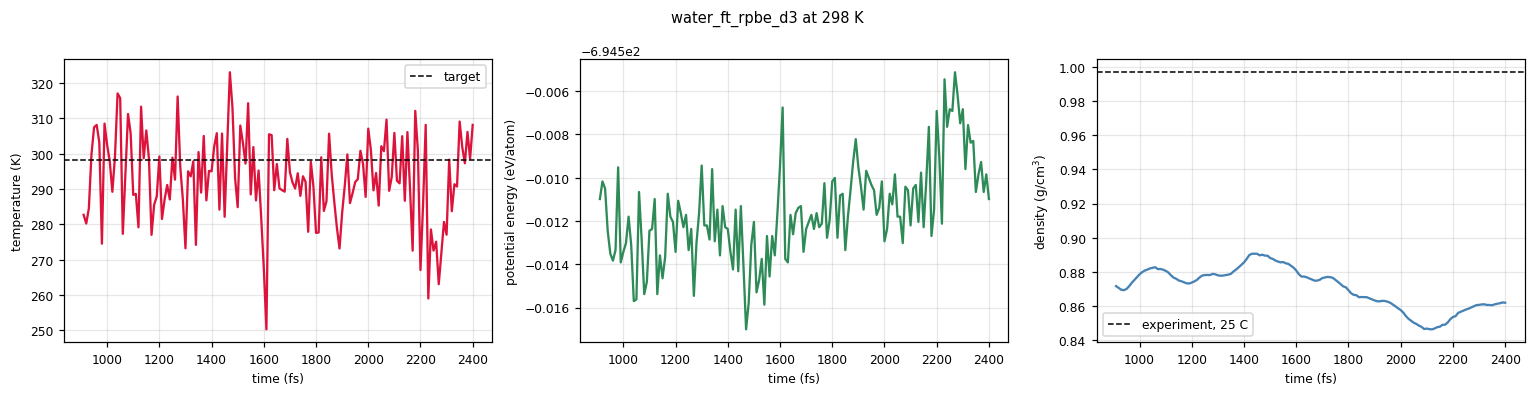

temperature  293.0 +/- 12.3 K (target 298.1)
energy drift 0.003 meV/atom per ps   (large and one-signed means trouble)
  converged: False   scatter 0.023, trend implies 0.020 across the window (tol 0.015), blocks ['0.873', '0.861', '0.849', '0.860']



In [ ]:
name = "water_ft_rpbe_d3" # TODO: look at the models in results.index!
tr = water_density[name]
plot_md(tr, f'{name} at {WATER_TEMP_K:.0f} K')
print(f'  converged: {tr["converged"]}   {tr.get("why", "")}\n')

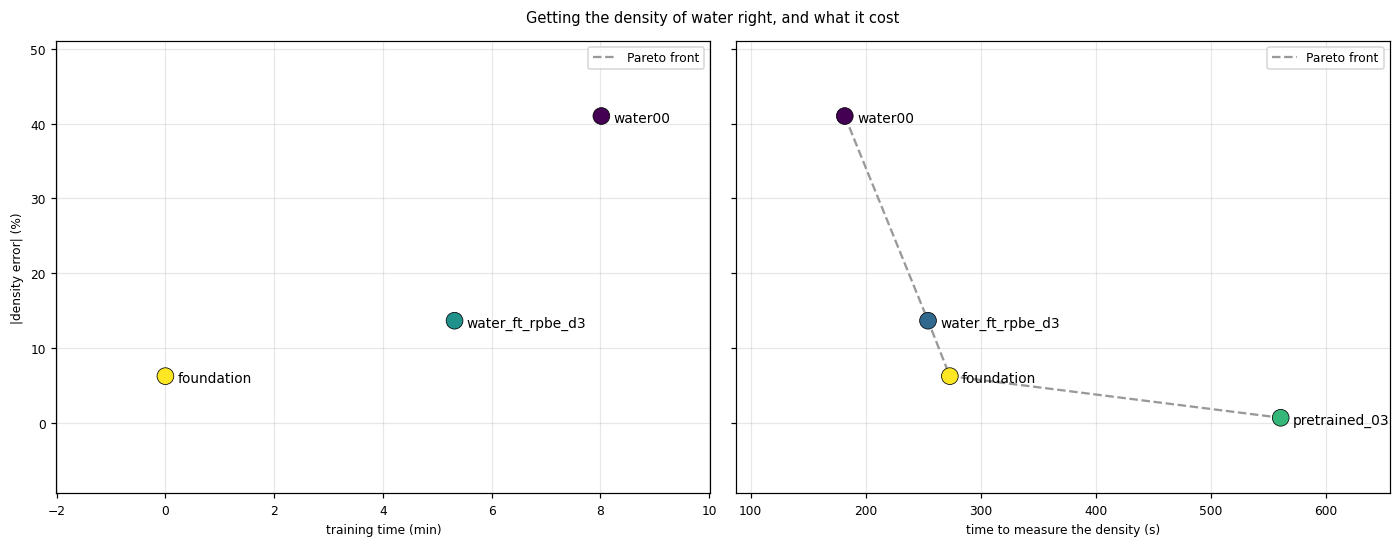

A model on the dashed line is not beaten on both axes at once by any other.
Anything above it is dominated: something else is cheaper AND more accurate.


In [ ]:
plot_water_pareto()

### Was the test set any use?

A held-out test set measures how well you reproduce your own reference on configurations
you did not train on. Necessary - a model failing it has learned nothing - but does it relate to error in density?

In [ ]:
rmse_vs_density()

pretrained_03: data/water_test_revpbe_d3.xyz is missing; rebuild it with make_training_set
foundation: data/water_test_revpbe_d3.xyz is missing; rebuild it with make_training_set
only 2 models have both a test error and a density; need three before the correlation says anything


##### Questions

1. Which lever moved the density most - data volume, level of theory, architecture, or
   fine-tuning? Is that the ranking you would have guessed from Part A?
2. Your baseline learned a force field faithfully. Did it beat a model that learned DFT
   badly? What does that say about where error comes from?
3. On the Pareto plot, is the most accurate model worth its cost? Would you choose
   differently for a calculation you had to run a thousand times?

### Export your results

One JSON per model, pooled across the class so we can look at the whole Pareto front. The record includes which dataset and training file each
model used, so the pooled plot can separate the levers. Make sure you click "allow multiple files to download", then upload the output JSONs to: https://drive.google.com/drive/u/1/folders/1vOSg-uokL7tuJXwJzVrv1JzSPqKhRW1G

In [ ]:
STUDENT_TAG = 'AG'      # your initials

export_water_results(list(WATER_MODELS))

wrote water_AG_water00_035641.json
wrote water_AG_water01_035641.json
wrote water_AG_water_ft_rpbe_d3_035641.json
! no log file for pretrained_03: set TRAINING_TIME_OVERRIDES['pretrained_03'] manually
wrote water_AG_pretrained_03_035641.json
wrote water_AG_foundation_035641.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Check Downloads, then upload these to the shared folder.


['water_AG_water00_035641.json',
 'water_AG_water01_035641.json',
 'water_AG_water_ft_rpbe_d3_035641.json',
 'water_AG_pretrained_03_035641.json',
 'water_AG_foundation_035641.json']

---

# Optional: your best model on other water phenomena

Everything above measured one number at one temperature. If you have time, the same model
can be pointed at harder questions - how density varies with temperature, whether it can
freeze or boil, and what happens to ice when you heat it.

Pick your best model and set it here! You can define best as cheapest to compute or best performance or a balance -- these cells will take some time to compute, so take that into consideration.

In [ ]:
BEST = 'water01'          # whichever you want!
BEST_CALC = WATER_MODELS[BEST]
BEST_FAST = MACECalculator(model_paths=[find_model(BEST)], device='cuda',
                           default_dtype='float32') if find_model(BEST) else BEST_CALC

## Density across the liquid range

One number could be luck. The *shape* of the curve is harder to fake: real water is
densest at 4 C and thins towards 100 C.

You already have 298 K. Add one more temperature and see whether the model moves in the
right direction. Each point takes a few minutes, so pick deliberately - somewhere near
0 C or near 100 C will tell you more than somewhere in the middle.

In [ ]:
EXTRA_T_C = 80.0        # your choice: try 0, 50, 80, 100

add_sweep_point(BEST, BEST_FAST, 25.0, box=WATER_BOX)     # the one you already know
add_sweep_point(BEST, BEST_FAST, EXTRA_T_C, box=WATER_BOX)

_display(sweep_table(BEST).round(4))
plot_sweep(BEST)

Add more points by calling `add_sweep_point(BEST, BEST_FAST, T)` again with a different
temperature - each one chains from the nearest one already measured, so it only has to
relax the difference.

**If the runs are too slow**, the cell below shows a sweep computed in advance on the
same protocol, so you can see the shape of the answer without waiting for it.

In [ ]:
df = precomputed_sweep_table('water_ft')
if df is not None:
    _CACHEdisplay(df.round(4))
    plot_sweep(df=df, title='precomputed sweep (FT on 250 frames of revpbe0-d3)')

##### Questions

1. Is the error a constant offset, or does it grow at one end? Those are different
   failures - a wrong equilibrium volume versus a wrong thermal expansion.
2. Which temperatures push the model outside the 0.84-0.997 g/cm3 range it trained on?
   Does the error grow there?

## Can you make it freeze or boil?

Water freezes at 0 C and boils at 100 C. Run your model well past both.

**Predict first.** Write down what you expect the density and the structure to do at
-20 C and at +120 C, and whether you expect to *see* a transition.

In [ ]:
FREEZE_T_K = 253.15      # -20 C
BOIL_T_K   = 393.15      # +120 C

attempts = {}
for tag, T in [('supercooled', FREEZE_T_K), ('superheated', BOIL_T_K)]:
    print(f'{tag} at {T-273.15:+.0f} C:')
    _, attempts[tag] = run_water_npt(tag, BEST_FAST, WATER_BOX, temp=T, prod=3000)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=110)
for a, key, ylab in [(ax[0], 'rho', r'density (g/cm$^3$)'),
                     (ax[1], 'order', 'fraction with 4 neighbours')]:
    for tag in attempts:
        a.plot(attempts[tag]['t_fs'], attempts[tag][key], label=tag)
    a.set_xlabel('time (fs)'); a.set_ylabel(ylab); a.grid(alpha=0.3); a.legend()
ax[1].set_ylim(0, 1); ax[0].axhline(0.917, ls=':', c='grey')
fig.suptitle('Supercooled and superheated water - does anything happen?')
plt.tight_layout(); plt.show()

for tag, tr in attempts.items():
    print(f'{tag:12s} {"ran away" if tr["diverged"] else "survived":9s} '
          f'density {np.mean(tr["rho"][-20:]):.3f}, ordered {np.mean(tr["order"][-20:]):.2f}')

In [ ]:
from ase.io import read as _read, write as _write
make_movie(attempts['superheated']['fname'], every=2)

##### What did you see?




## Melting ice
Ice typically needs a nucleation site and longer to form. Clean water
can supercool to nearly -40 C!

Melting needs no nucleus in the same sense: a crystal above its melting point comes apart
from its own surfaces and defects, everywhere at once, in picoseconds. That is a timescale we can model with MD.

In [ ]:
ICE = reorder_molecules(build_ice(n_cells=2, seed=0))     # 64 molecules of cubic ice
show_traj(ICE)

In [ ]:
MELT_T_K = 350        # above melting, below where the box starts running away

fname, melt = run_water_npt('ice_melt', BEST_FAST, ICE, temp=MELT_T_K,
                            equil=0, prod=4000, every=20)

fig, ax = plt.subplots(1, 2, figsize=(12, 4), dpi=110)
ax[0].plot(melt['t_fs'], melt['order'], color='crimson')
ax[0].set_ylabel('fraction with 4 neighbours'); ax[0].set_ylim(0, 1)
ax[1].plot(melt['t_fs'], melt['rho'], color='steelblue')
ax[1].axhline(0.917, ls=':', c='grey', label='ice')
ax[1].axhline(0.997, ls='--', c='k', label='liquid water, 25 C')
ax[1].set_ylabel(r'density (g/cm$^3$)'); ax[1].legend()
for a in ax:
    a.set_xlabel('time (fs)'); a.grid(alpha=0.3)
fig.suptitle(f'Melting ice at {MELT_T_K-273.15:.0f} C')
plt.tight_layout(); plt.show()

print(f'ordered fraction {melt["order"][0]:.2f} -> {np.mean(melt["order"][-10:]):.2f}')

In [ ]:
make_movie(fname)

Output hidden; open in https://colab.research.google.com to view.

##### Questions

1. When does the ordered fraction collapse - gradually or suddenly?
2. In the movie, does the crystal come apart uniformly or from particular places?
3. The density *rises* as ice melts. Water is one of very few substances whose solid
   floats. Does your model reproduce that?
4. Lower `MELT_T_K` until melting no longer happens within the run. Is the temperature
   you find the melting point, or an upper bound on it?

## Supplying the nucleus: ice and liquid together

Freezing failed because no nucleus could form. Can we try building in a nucleation site: **half crystal, half
liquid, sharing an interface**, made by holding the bottom half of an ice slab fixed and melting the top half against it.

The structure is only a starting geometry, so it is built with the most reliable model
available rather than the one under test. A model that has never seen ice can produce
nonsense at melting temperatures and hand back a slab with dissociated molecules.

In [ ]:
BUILDER = WATER_MODELS.get('pretrained_03', BEST_CALC)

SLAB = build_ice_liquid_interface(BUILDER, n_cells=2, stack=2,
                                  melt_T=450.0, melt_steps=5000, seed=0)
show_traj(SLAB)

ice Ic: 64 molecules, cubic cell 12.75 A, density 0.924 g/cm3 (real ice Ih is 0.917)
  H-O-H opens to the tetrahedral 109.5 deg rather than water's 104.5 deg; the first few fs of MD relax that.
slab: 128 molecules, cell [12.75 12.75 25.5 ] A
  holding 72 molecules fixed, melting 56 at 450 K
  order along z: 0.94 1.00 1.00 1.00 1.00 0.88 0.44 0.70 0.50 0.88
  (want high in the first half, low in the second)
  slab: 128 intact molecules, closest contact 0.94 A, density 0.924 g/cm3


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

**One expectation to set before you run.** We weren't able to see ice grow with our tests -- just melt. But try it for yourself -- change "COEX_T" to observe the changes at different temperatures.

coexistence at -13 C:
  coex_260K         6.39 min   <T> =  258.9 K   rho_final = 0.845 g/cm3
coexistence at +7 C:
  coex_280K         6.38 min   <T> =  278.7 K   rho_final = 0.845 g/cm3
coexistence at +27 C:
  coex_300K         6.34 min   <T> =  297.8 K   rho_final = 0.831 g/cm3


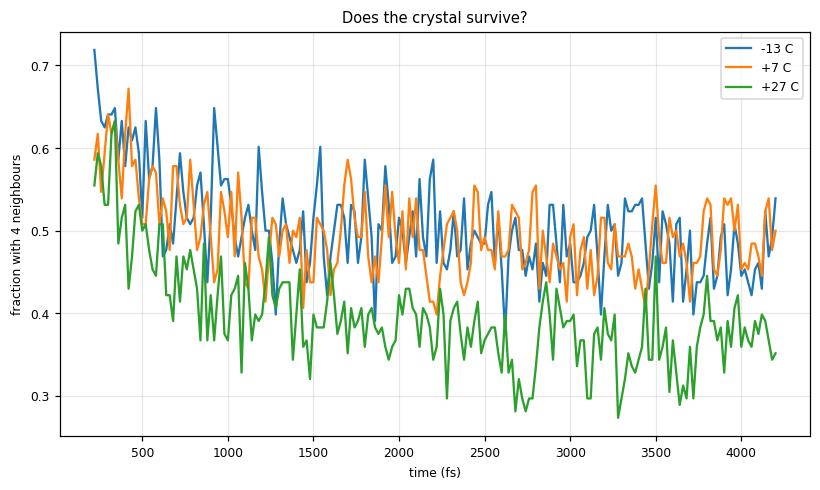

In [ ]:
COEX_T = [240.0, 280.0, 350.0]

coex = {}
for T in COEX_T:
    print(f'coexistence at {T-273.15:+.0f} C:')
    fn, coex[T] = run_water_npt(f'coex_{int(T)}K', BEST_FAST, SLAB,
                                temp=T, equil=200, prod=4000, every=20)
    coex[T]['fname'] = fn

plt.figure(figsize=(7.5, 4.5), dpi=110)
for T in COEX_T:
    plt.plot(coex[T]['t_fs'], coex[T]['order'], label=f'{T-273.15:+.0f} C')
plt.xlabel('time (fs)'); plt.ylabel('fraction with 4 neighbours')
plt.title('Does the crystal survive?')
plt.grid(alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()

In [ ]:
# Project along x-z so the interface is edge-on and the front is visible.
make_movie(coex[COEX_T[0]]['fname'], every=2, axes=(0, 2),
           title=f'coexistence at {COEX_T[0]-273.15:+.0f} C')

Output hidden; open in https://colab.research.google.com to view.

##### Questions

1. Where does your extrapolated melting point land relative to 273 K? A model that gets
   the density right can still melt at the wrong temperature.
2. Earlier, bulk ice needed a much higher temperature before anything happened in 4 ps.
   Why does the interface move at temperatures where bulk ice sat there indefinitely?
3. Try a much colder run - 150 K, say - and watch the ordered fraction. It may *rise*.
   Before calling that freezing: at 150 K the liquid is glassy, and the order parameter
   counts neighbours in a distance window that narrows as thermal motion dies down.
   How would you tell vitrification from crystal growth? (`order_profile` along z is a
   good start: growth advances a front, vitrification stiffens everywhere at once.)